# Data Preprocessing\nImport libraries and prepare data for fraud detection modeling.

In [3]:
# Core data handling
import pandas as pd
import numpy as np

# Preprocessing & feature engineering
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Train/test split & cross-validation
from sklearn.model_selection import train_test_split, StratifiedKFold

# Handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Date/time utilities
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [4]:

cust_data  = pd.read_csv('../data/customers.csv')
acc_data   = pd.read_csv('../data/accounts.csv')                                                                                                    
txn_data   = pd.read_csv('../data/transactions.csv')


In [5]:
print(f"customers    : {cust_data.shape}")
print(f"accounts     : {acc_data.shape}")
print(f"transactions : {txn_data.shape}")

customers    : (100000, 8)
accounts     : (150000, 6)
transactions : (5000000, 20)


In [6]:
cust_data.head()

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since
0,CUST000001,working_adult,32.0000,40063,711,Employed,South East,2008-09-04
1,CUST000002,retired,82.0000,24101,721,Retired,East Midlands,2021-08-17
2,CUST000003,established,64.0000,77965,847,Self-Employed,Wales,2013-06-06
3,CUST000004,working_adult,46.0000,69238,775,Employed,South West,2018-08-12
4,CUST000005,young_adult,25.0000,18823,584,Self-Employed,North West,2015-03-19


In [7]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   customer_id     100000 non-null  object 
 1   segment         100000 non-null  object 
 2   customer_age    99000 non-null   float64
 3   annual_income   100000 non-null  int64  
 4   credit_score    100000 non-null  int64  
 5   occupation      100000 non-null  object 
 6   region          100000 non-null  object 
 7   customer_since  100000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.1+ MB


In [8]:
cust_data['customer_since'] = pd.to_datetime(cust_data['customer_since'])

In [9]:
cust_data['cust_tenure_days'] = (cust_data['customer_since'].max() - cust_data['customer_since']).dt.days    

In [10]:
cust_data['cust_tenure_years'] = (cust_data['customer_since'].max() - cust_data['customer_since']).dt.days  / 365.25

In [11]:
cust_data['customer_age'].describe()

count   99000.0000
mean       44.2131
std        16.6412
min        18.0000
25%        30.0000
50%        43.0000
75%        56.0000
max        85.0000
Name: customer_age, dtype: float64

In [12]:
cust_data.head()

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since,cust_tenure_days,cust_tenure_years
0,CUST000001,working_adult,32.0000,40063,711,Employed,South East,2008-09-04,5052,13.8316
1,CUST000002,retired,82.0000,24101,721,Retired,East Midlands,2021-08-17,322,0.8816
2,CUST000003,established,64.0000,77965,847,Self-Employed,Wales,2013-06-06,3316,9.0787
3,CUST000004,working_adult,46.0000,69238,775,Employed,South West,2018-08-12,1423,3.8960
4,CUST000005,young_adult,25.0000,18823,584,Self-Employed,North West,2015-03-19,2665,7.2964


In [13]:
cust_data['cust_tenure_days'].describe()

count   100000.0000
mean      2650.8993
std       1527.1577
min          0.0000
25%       1335.0000
50%       2644.0000
75%       3980.0000
max       5294.0000
Name: cust_tenure_days, dtype: float64

In [14]:
acc_data.head()

,account_id,customer_id,account_type,account_open_date,account_balance,account_status
0,ACC0000001,CUST000001,Current,2018-03-25,20769.9000,Active
1,ACC0000002,CUST000002,Current,2017-05-19,31048.5700,Active
2,ACC0000003,CUST000003,Current,2014-12-31,47146.9500,Active
3,ACC0000004,CUST000004,Current,2021-01-05,1151.7100,Active
4,ACC0000005,CUST000005,Current,2019-04-13,966.3700,Active


In [15]:
acc_data.groupby('customer_id')['account_id'].count().sort_values(ascending=False).head(10)   


customer_id
CUST100000    3
CUST093330    3
CUST093337    3
CUST093336    3
CUST093335    3
CUST093334    3
CUST093333    3
CUST093332    3
CUST093331    3
CUST093329    3
Name: account_id, dtype: int64

In [16]:
txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0


In [17]:
def missing_values(datasets):
    try:
        for df in datasets:
            print(df.isna().sum())
            print()
    except Exception as e:
        print(e)

datasets = [cust_data, acc_data, txn_data]
missing_values(datasets)

customer_id             0
segment                 0
customer_age         1000
annual_income           0
credit_score            0
occupation              0
region                  0
customer_since          0
cust_tenure_days        0
cust_tenure_years       0
dtype: int64

account_id           0
customer_id          0
account_type         0
account_open_date    0
account_balance      0
account_status       0
dtype: int64

transaction_id                      0
account_id                          0
timestamp                           0
amount                         100000
transaction_type                    0
merchant_category               50000
merchant_id                         0
currency                            0
is_foreign_currency                 0
hour_of_day                         0
day_of_week                         0
is_weekend                          0
days_since_last_transaction         0
previous_transaction_amount         0
login_attempts                      0
devi

In [18]:
txn_data['amount'].describe()

count   4900000.0000
mean        163.3939
std         407.4722
min           3.0000
25%          26.4400
50%          61.3400
75%         163.1000
max       10000.0000
Name: amount, dtype: float64

In [19]:
# missing amount replacement account level median value
txn_data['amount'] = txn_data.groupby('account_id')['amount'].transform(                                                                          
        lambda x: x.fillna(x.median())                                                                                                                
    ) 


In [20]:
txn_data['amount'].isna().sum()

np.int64(0)

In [21]:
# missing values checks in merchant category

txn_data['merchant_category'].unique()

array(['ATM Withdrawal', 'Restaurant/Cafe', 'Supermarket',
       'Travel/Hotels', 'Utilities/Bills', 'Transfer', 'Online Retail',
       'Crypto/Gaming', 'Other', 'Transport/Fuel', 'Healthcare',
       'Entertainment', nan], dtype=object)

<Axes: xlabel='merchant_category'>

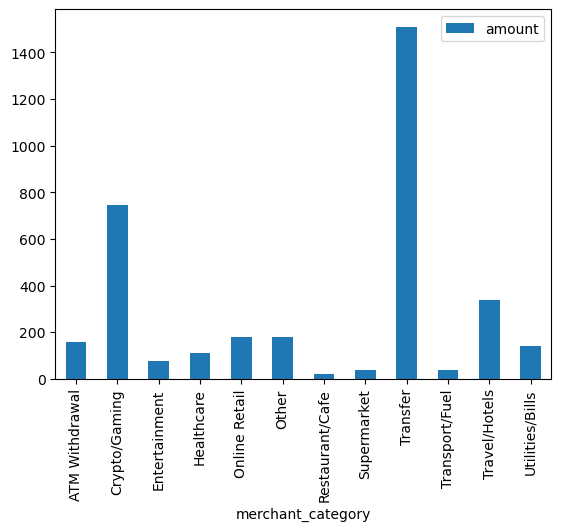

In [22]:
txn_data.groupby('merchant_category').agg({'amount':'mean'}).plot(kind='bar')

In [23]:
# Fill missing merchant_category based on nearest average amount per category
category_avg = txn_data.groupby('merchant_category')['amount'].mean()

def nearest_category(amount):
    return (category_avg - amount).abs().idxmin()

null_mask = txn_data['merchant_category'].isna()
txn_data.loc[null_mask, 'merchant_category'] = (
    txn_data.loc[null_mask, 'amount'].apply(nearest_category)
)

print(f"Remaining nulls in merchant_category: {txn_data['merchant_category'].isna().sum()}")

Remaining nulls in merchant_category: 0


In [24]:
txn_data.isna().sum()

transaction_id                 0
account_id                     0
timestamp                      0
amount                         0
transaction_type               0
merchant_category              0
merchant_id                    0
currency                       0
is_foreign_currency            0
hour_of_day                    0
day_of_week                    0
is_weekend                     0
days_since_last_transaction    0
previous_transaction_amount    0
login_attempts                 0
device_change_flag             0
location_change_flag           0
ip_country_mismatch            0
failed_pin_attempts            0
is_fraud                       0
dtype: int64

In [25]:
# Fill missing customer_age with median grouped by segment
print(f"Nulls before: {cust_data['customer_age'].isna().sum()}")

cust_data['customer_age'] = cust_data.groupby('segment')['customer_age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Nulls after: {cust_data['customer_age'].isna().sum()}")

Nulls before: 1000
Nulls after: 0


In [26]:
#  Nulls are set.

In [27]:
# Drop duplicates
cust_data.drop_duplicates(inplace=True)
acc_data.drop_duplicates(inplace=True)
txn_data.drop_duplicates(inplace=True)

print(f"cust_data : {cust_data.shape}")
print(f"acc_data  : {acc_data.shape}")
print(f"txn_data  : {txn_data.shape}")

cust_data : (100000, 10)
acc_data  : (150000, 6)
txn_data  : (5000000, 20)


In [28]:
# Checking the data types

In [29]:
cust_data.dtypes                                                                                                                     

customer_id                  object
segment                      object
customer_age                float64
annual_income                 int64
credit_score                  int64
occupation                   object
region                       object
customer_since       datetime64[ns]
cust_tenure_days              int64
cust_tenure_years           float64
dtype: object

In [30]:
cust_data['customer_age']   = cust_data['customer_age'].astype('int64')
cust_data['annual_income']  = cust_data['annual_income'].astype('int64')                                                                            
cust_data['credit_score']   = cust_data['credit_score'].astype('int64')  

In [31]:
acc_data.dtypes

account_id            object
customer_id           object
account_type          object
account_open_date     object
account_balance      float64
account_status        object
dtype: object

In [32]:
# Check txn_data dtypes
print(txn_data.dtypes)

transaction_id                  object
account_id                      object
timestamp                       object
amount                         float64
transaction_type                object
merchant_category               object
merchant_id                     object
currency                        object
is_foreign_currency              int64
hour_of_day                      int64
day_of_week                      int64
is_weekend                       int64
days_since_last_transaction      int64
previous_transaction_amount    float64
login_attempts                   int64
device_change_flag               int64
location_change_flag             int64
ip_country_mismatch              int64
failed_pin_attempts              int64
is_fraud                         int64
dtype: object


In [33]:
# Fix dtypes
txn_data['is_fraud'] = txn_data['is_fraud'].astype('object')
txn_data['timestamp'] = pd.to_datetime(txn_data['timestamp'])
txn_data['amount']    = txn_data['amount'].astype('float64')
txn_data['previous_transaction_amount'] = txn_data['previous_transaction_amount'].astype('float64')

int_cols = [
    'is_foreign_currency', 'hour_of_day', 'day_of_week', 'is_weekend',
    'days_since_last_transaction', 'login_attempts', 'device_change_flag',
    'location_change_flag', 'ip_country_mismatch', 'failed_pin_attempts'
]
txn_data[int_cols] = txn_data[int_cols].astype('int64')

print("\nUpdated dtypes:")
print(txn_data.dtypes)


Updated dtypes:
transaction_id                         object
account_id                             object
timestamp                      datetime64[ns]
amount                                float64
transaction_type                       object
merchant_category                      object
merchant_id                            object
currency                               object
is_foreign_currency                     int64
hour_of_day                             int64
day_of_week                             int64
is_weekend                              int64
days_since_last_transaction             int64
previous_transaction_amount           float64
login_attempts                          int64
device_change_flag                      int64
location_change_flag                    int64
ip_country_mismatch                     int64
failed_pin_attempts                     int64
is_fraud                               object
dtype: object


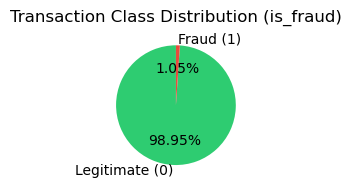

is_fraud
Legitimate    4947295
Fraud           52705
Name: count, dtype: int64


In [34]:
# Plot is_fraud class distribution
fraud_counts = txn_data['is_fraud'].value_counts()
fraud_pct    = txn_data['is_fraud'].value_counts(normalize=True) * 100

labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(4, 2))
plt.pie(fraud_pct, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Transaction Class Distribution (is_fraud)')
plt.tight_layout()
plt.show()

print(fraud_counts.rename({0: 'Legitimate', 1: 'Fraud'}))

In [35]:
cust_data.head()

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since,cust_tenure_days,cust_tenure_years
0,CUST000001,working_adult,32,40063,711,Employed,South East,2008-09-04,5052,13.8316
1,CUST000002,retired,82,24101,721,Retired,East Midlands,2021-08-17,322,0.8816
2,CUST000003,established,64,77965,847,Self-Employed,Wales,2013-06-06,3316,9.0787
3,CUST000004,working_adult,46,69238,775,Employed,South West,2018-08-12,1423,3.8960
4,CUST000005,young_adult,25,18823,584,Self-Employed,North West,2015-03-19,2665,7.2964


In [36]:
# Now, Customer data exploration

In [37]:
acc_data.columns

Index(['account_id', 'customer_id', 'account_type', 'account_open_date',
       'account_balance', 'account_status'],
      dtype='object')

In [38]:
fraud_per_customer = (                                                                                                                              
      txn_data[['account_id', 'is_fraud']]    
      .merge(acc_data[['account_id', 'customer_id']], on='account_id', how='left')                                                                    
      .groupby('customer_id')['is_fraud']                                                                                                             
      .max()  # 1 if any fraud, 0 if none                                                                                                             
      .reset_index()                                                                                                                                  
  )                                                                                                                                                   
                                          
cust_data_fraud = cust_data.merge(fraud_per_customer, on='customer_id', how='left')

In [39]:
cust_data_fraud.shape

(100000, 11)

In [40]:
cust_data_fraud.head()

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since,cust_tenure_days,cust_tenure_years,is_fraud
0,CUST000001,working_adult,32,40063,711,Employed,South East,2008-09-04,5052,13.8316,0
1,CUST000002,retired,82,24101,721,Retired,East Midlands,2021-08-17,322,0.8816,0
2,CUST000003,established,64,77965,847,Self-Employed,Wales,2013-06-06,3316,9.0787,0
3,CUST000004,working_adult,46,69238,775,Employed,South West,2018-08-12,1423,3.8960,1
4,CUST000005,young_adult,25,18823,584,Self-Employed,North West,2015-03-19,2665,7.2964,0


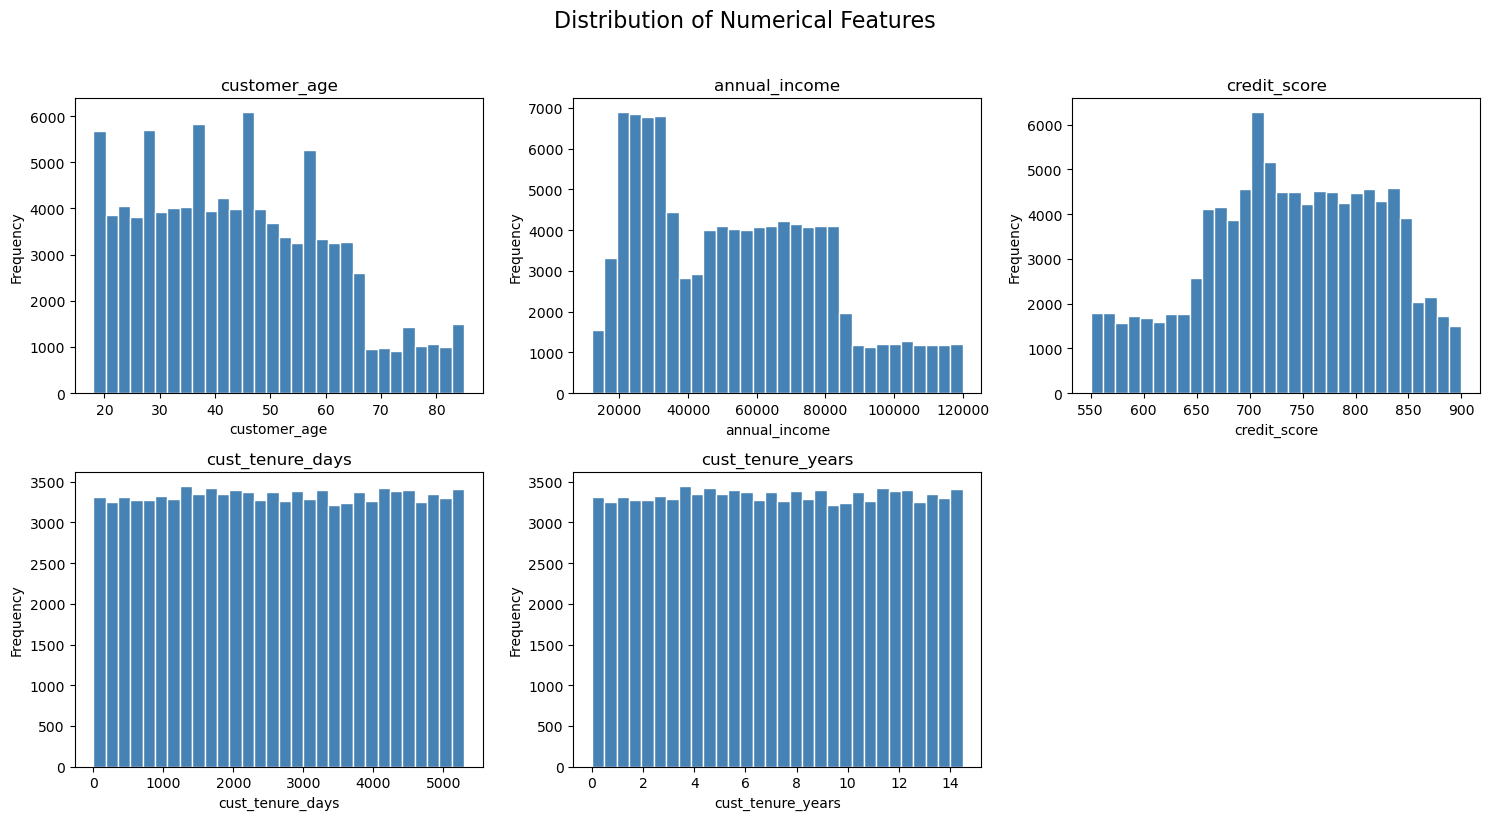

In [41]:
# Histogram for all numerical columns in cust_data_fraud
num_cols = cust_data_fraud.select_dtypes(include='number').columns.tolist()

n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(cust_data_fraud[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Unique value counts for categorical columns
cat_cols = cust_data_fraud.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"{col} ({cust_data_fraud[col].nunique()} unique):")
    print(cust_data_fraud[col].value_counts())
    print()

customer_id (100000 unique):
customer_id
CUST000001    1
CUST066651    1
CUST066673    1
CUST066672    1
CUST066671    1
             ..
CUST033332    1
CUST033331    1
CUST033330    1
CUST033329    1
CUST100000    1
Name: count, Length: 100000, dtype: int64

segment (4 unique):
segment
working_adult    39992
established      25136
young_adult      25046
retired           9826
Name: count, dtype: int64

occupation (6 unique):
occupation
Employed         49746
Self-Employed    17469
Retired           9640
Student           8644
Unemployed        8197
Part-Time         6304
Name: count, dtype: int64

region (12 unique):
region
London              19944
South East          14090
North West          11074
Yorkshire            8108
West Midlands        7947
East of England      7920
Scotland             7042
South West           6989
East Midlands        6982
Wales                3961
North East           3919
Northern Ireland     2024
Name: count, dtype: int64

is_fraud (2 unique):
is_frau

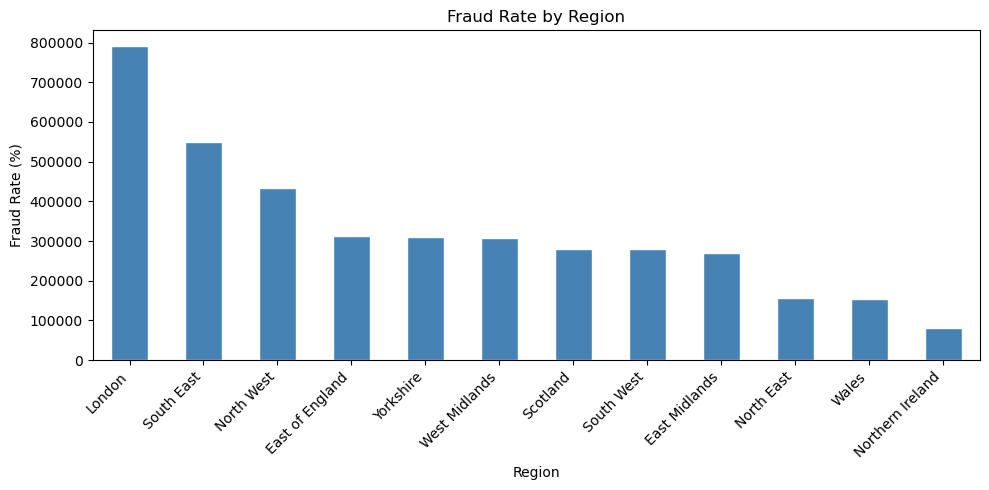

In [43]:
# Fraud rate by region
fraud_by_region = cust_data_fraud.groupby('region')['is_fraud'].sum().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
fraud_by_region.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Region')
plt.xlabel('Region')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

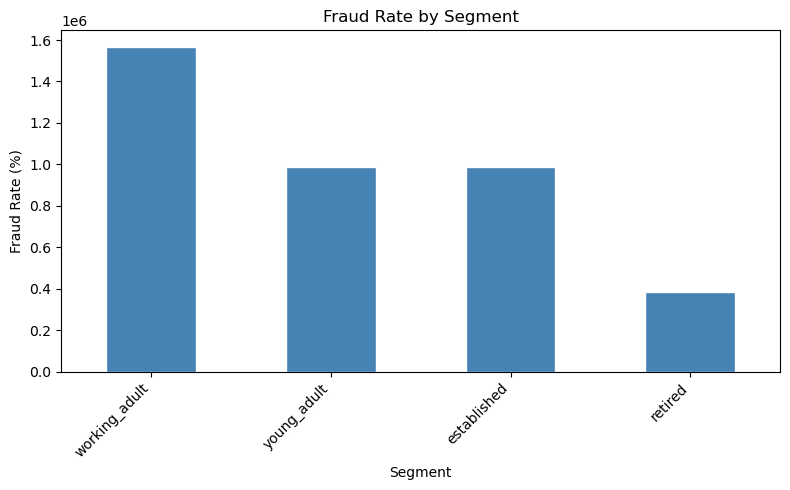

In [44]:
# Fraud rate by segment
fraud_by_segment = cust_data_fraud.groupby('segment')['is_fraud'].sum().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
fraud_by_segment.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Segment')
plt.xlabel('Segment')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

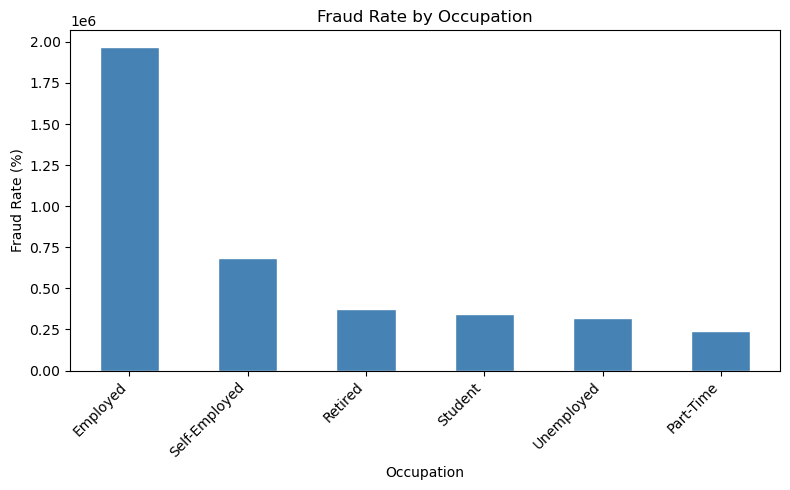

In [45]:
# Fraud rate by occupation
fraud_by_occupation = cust_data_fraud.groupby('occupation')['is_fraud'].sum().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
fraud_by_occupation.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
# Lets explore acc_data

acc_data.head()

,account_id,customer_id,account_type,account_open_date,account_balance,account_status
0,ACC0000001,CUST000001,Current,2018-03-25,20769.9000,Active
1,ACC0000002,CUST000002,Current,2017-05-19,31048.5700,Active
2,ACC0000003,CUST000003,Current,2014-12-31,47146.9500,Active
3,ACC0000004,CUST000004,Current,2021-01-05,1151.7100,Active
4,ACC0000005,CUST000005,Current,2019-04-13,966.3700,Active


In [47]:
fraud_per_account = txn_data.groupby('account_id')['is_fraud'].max().reset_index()                                                                  
                                                                                                                                                      
acc_data_fraud = acc_data.merge(fraud_per_account, on='account_id', how='left')                                                                     
print(acc_data_fraud.shape)

(150000, 7)


In [48]:
acc_data_fraud.head()

,account_id,customer_id,account_type,account_open_date,account_balance,account_status,is_fraud
0,ACC0000001,CUST000001,Current,2018-03-25,20769.9000,Active,0
1,ACC0000002,CUST000002,Current,2017-05-19,31048.5700,Active,0
2,ACC0000003,CUST000003,Current,2014-12-31,47146.9500,Active,0
3,ACC0000004,CUST000004,Current,2021-01-05,1151.7100,Active,1
4,ACC0000005,CUST000005,Current,2019-04-13,966.3700,Active,0


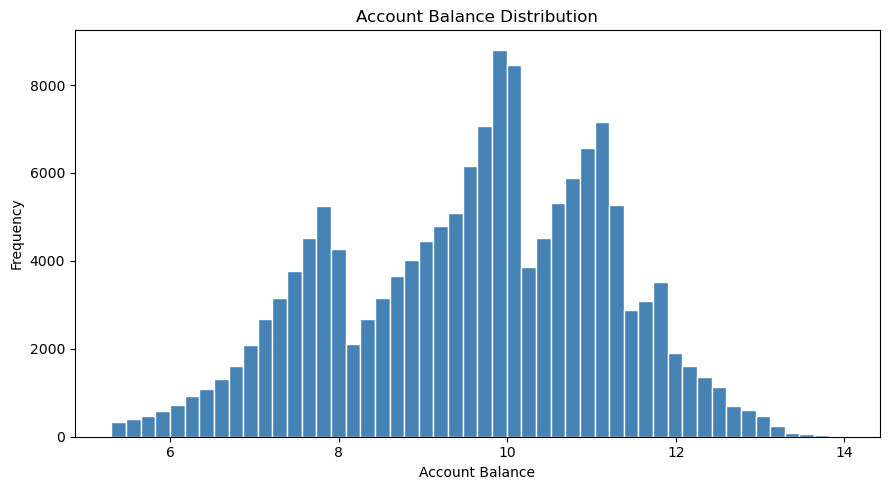

In [49]:
# Account balance distribution - normalised
plt.figure(figsize=(9, 5))
plt.hist(np.log1p(acc_data_fraud['account_balance'].dropna()), bins=50, color='steelblue', edgecolor='white')
plt.title('Account Balance Distribution')
plt.xlabel('Account Balance')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

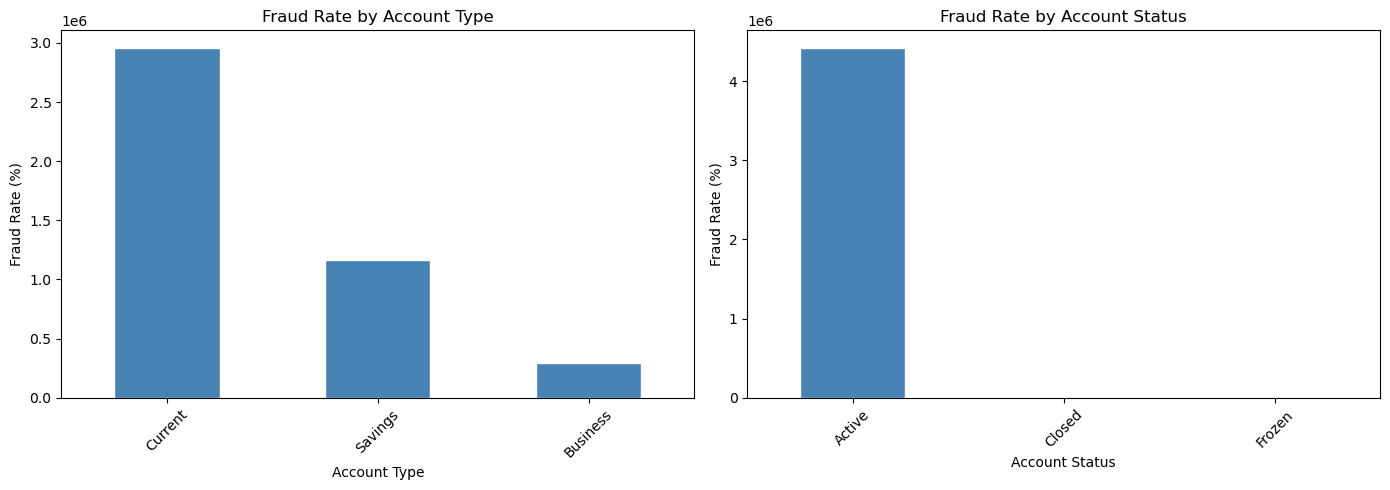

In [50]:
# Fraud rate by account_type and account_status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Account type
fraud_by_type = acc_data_fraud.groupby('account_type')['is_fraud'].sum().sort_values(ascending=False) * 100
fraud_by_type.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Fraud Rate by Account Type')
axes[0].set_xlabel('Account Type')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Account status
fraud_by_status = acc_data_fraud.groupby('account_status')['is_fraud'].sum().sort_values(ascending=False) * 100
fraud_by_status.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate by Account Status')
axes[1].set_xlabel('Account Status')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [51]:
#  Lets explore txn_data

txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0


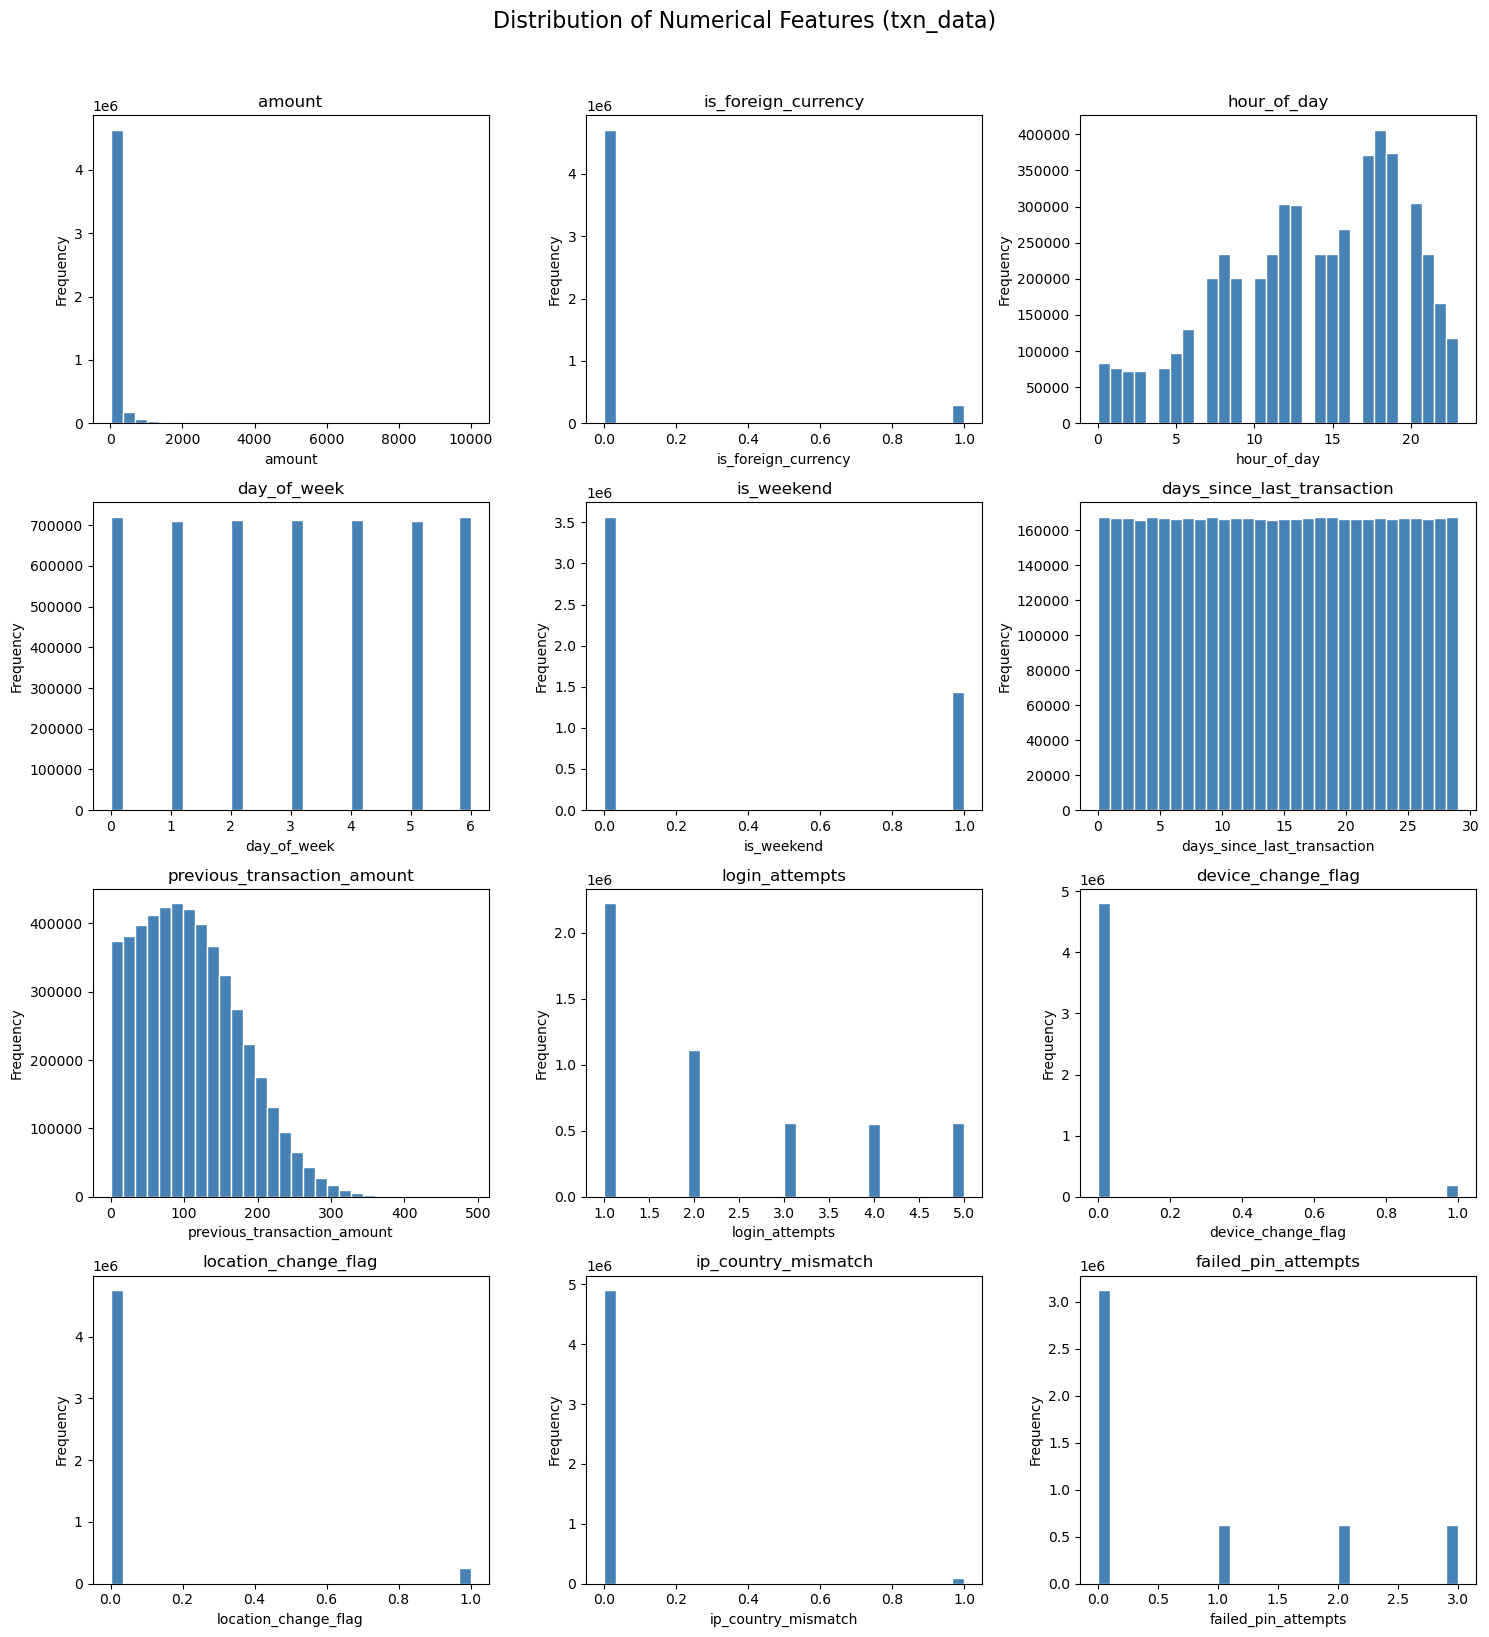

In [52]:
# Histograms for numerical features in txn_data
num_cols = txn_data.select_dtypes(include='number').columns.tolist()

n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(txn_data[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features (txn_data)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# Customer with maximum number of transactions
txn_with_customer = txn_data.merge(acc_data[['account_id', 'customer_id']], on='account_id', how='left')

top_customers = (
    txn_with_customer.groupby('customer_id')['transaction_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'transaction_id': 'num_transactions'})
)

print(top_customers.head(10))

  customer_id  num_transactions
0  CUST090205               143
1  CUST096310               143
2  CUST094089               142
3  CUST097296               142
4  CUST096984               140
5  CUST096299               140
6  CUST092227               139
7  CUST092741               139
8  CUST092569               137
9  CUST098347               136


In [54]:
# Get accounts belonging to the target customer
target_accounts = acc_data[acc_data['customer_id'] == 'CUST090205']['account_id']

# Filter transactions for those accounts
txn_top_cust = txn_data[txn_data['account_id'].isin(target_accounts)]
print(txn_top_cust.shape)
txn_top_cust.head()

(143, 20)


,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud
24875,TXN00024876,ACC0120614,2024-07-04 17:26:08,340.1500,Transfer,Online Retail,MER10934,GBP,0,17,3,0,9,218.5100,1,0,0,0,1,0
41891,TXN00041892,ACC0120615,2023-06-17 02:04:12,63.5600,POS,ATM Withdrawal,MER13306,USD,1,15,5,1,15,81.9100,2,0,0,0,0,0
63982,TXN00063983,ACC0120615,2024-02-21 16:20:41,174.5700,Online,Online Retail,MER03780,GBP,0,22,2,0,8,41.0300,2,0,0,0,1,0
74545,TXN00074546,ACC0120615,2023-06-21 16:14:33,155.9500,POS,Utilities/Bills,MER12119,GBP,0,19,2,0,13,76.9800,3,0,0,0,0,0
136182,TXN00136183,ACC0120614,2023-03-19 06:20:09,20.9600,Transfer,Transport/Fuel,MER09722,GBP,0,6,6,1,20,3.6100,1,0,0,0,1,0


Top active customer: CUST090205


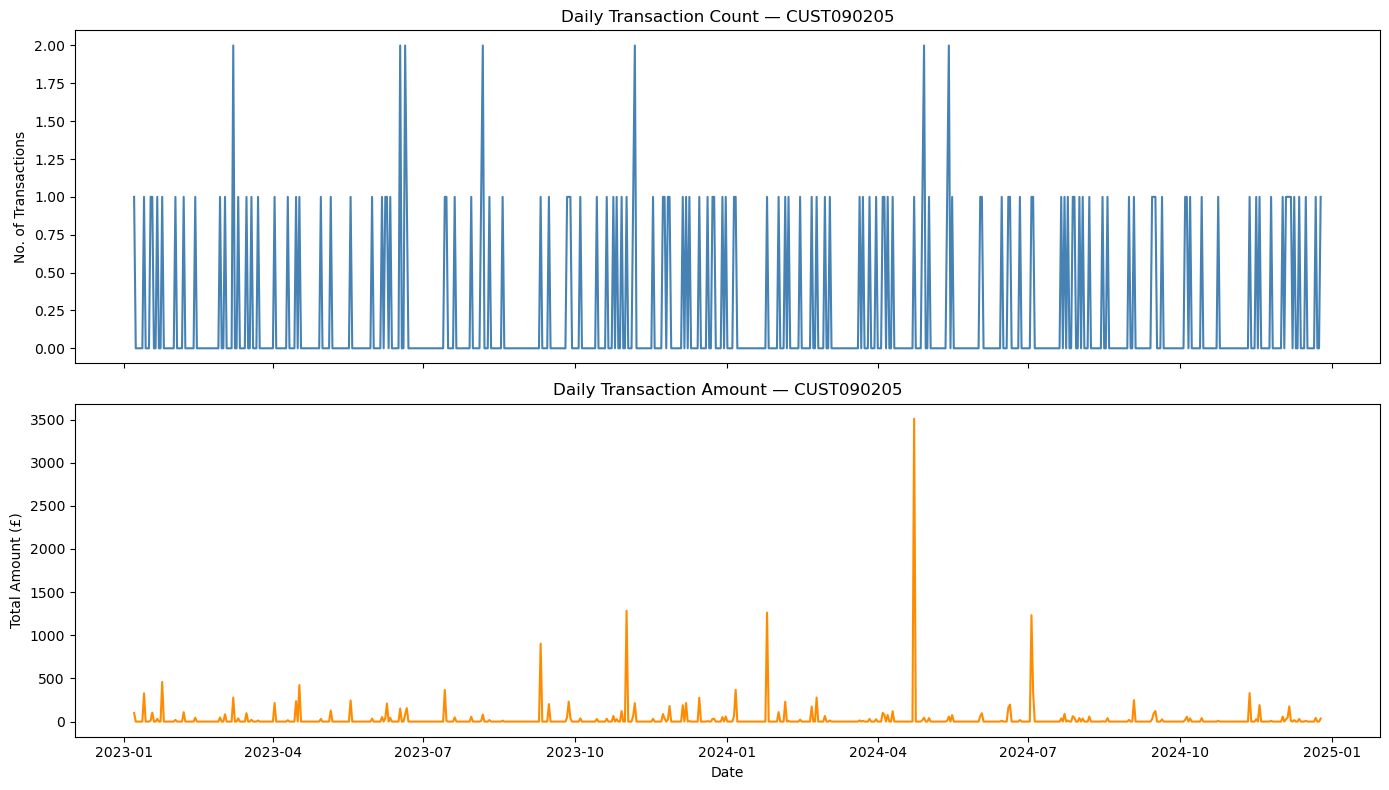

In [55]:
# Step 1: Find the most active customer (max transactions, active accounts only)
active_accounts = acc_data[acc_data['account_status'] == 'Active'][['account_id', 'customer_id']]

txn_with_cust = txn_data.merge(active_accounts, on='account_id', how='inner')

top_customer = (
    txn_with_cust.groupby('customer_id')['transaction_id']
    .count()
    .idxmax()
)
print(f"Top active customer: {top_customer}")

# Step 2: Get their transactions
cust_txns = txn_with_cust[txn_with_cust['customer_id'] == top_customer].copy()
cust_txns['timestamp'] = pd.to_datetime(cust_txns['timestamp'])
cust_txns = cust_txns.sort_values('timestamp')

# Step 3: Resample to daily transaction count and amount
cust_txns.set_index('timestamp', inplace=True)
daily_count  = cust_txns['transaction_id'].resample('D').count()
daily_amount = cust_txns['amount'].resample('D').sum()

# Step 4: Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_count.index, daily_count.values, color='steelblue')
axes[0].set_title(f'Daily Transaction Count — {top_customer}')
axes[0].set_ylabel('No. of Transactions')

axes[1].plot(daily_amount.index, daily_amount.values, color='darkorange')
axes[1].set_title(f'Daily Transaction Amount — {top_customer}')
axes[1].set_ylabel('Total Amount (£)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

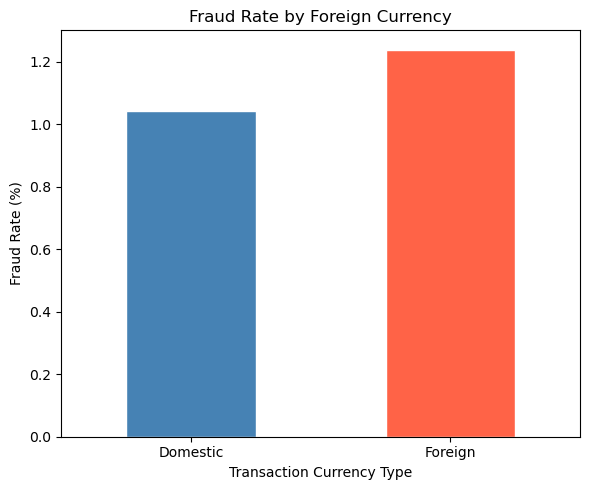

Domestic   1.0423
Foreign    1.2392
Name: is_fraud, dtype: object


In [56]:
# Fraud rate by foreign currency flag
fraud_by_currency = txn_data.groupby('is_foreign_currency')['is_fraud'].mean() * 100
fraud_by_currency.index = ['Domestic', 'Foreign']

plt.figure(figsize=(6, 5))
fraud_by_currency.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Fraud Rate by Foreign Currency')
plt.xlabel('Transaction Currency Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(fraud_by_currency)

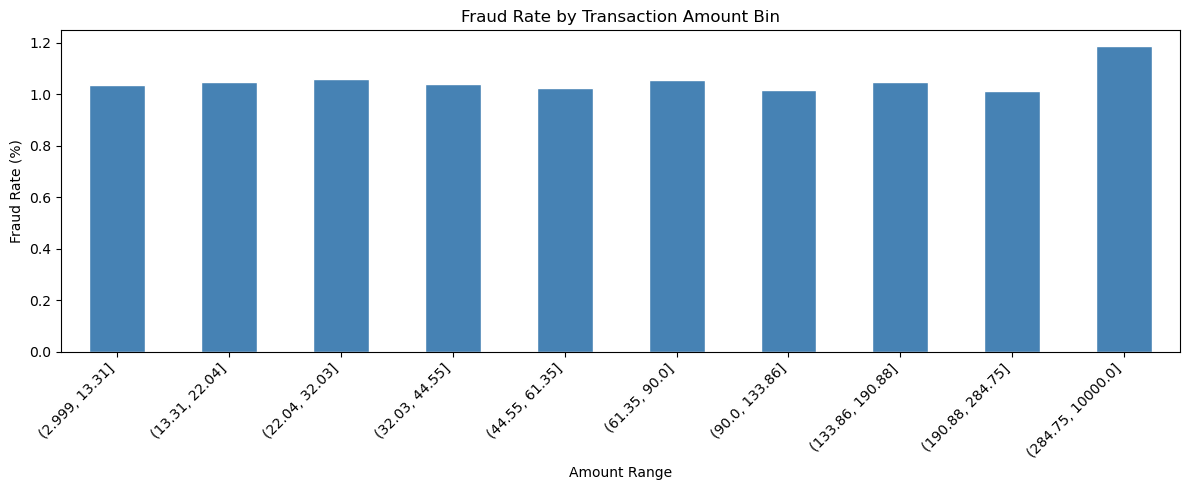

amount_bin
(2.999, 13.31]      1.0380
(13.31, 22.04]      1.0497
(22.04, 32.03]      1.0597
(32.03, 44.55]      1.0408
(44.55, 61.35]      1.0265
(61.35, 90.0]       1.0558
(90.0, 133.86]      1.0183
(133.86, 190.88]    1.0469
(190.88, 284.75]    1.0149
(284.75, 10000.0]   1.1896
Name: is_fraud, dtype: object


In [57]:
# Fraud rate by amount bins (10 equal-frequency bins using qcut)
txn_data['amount_bin'] = pd.qcut(txn_data['amount'], q=10, duplicates='drop')

fraud_by_amount_bin = txn_data.groupby('amount_bin')['is_fraud'].mean().sort_index() * 100

plt.figure(figsize=(12, 5))
fraud_by_amount_bin.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Transaction Amount Bin')
plt.xlabel('Amount Range')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(fraud_by_amount_bin)

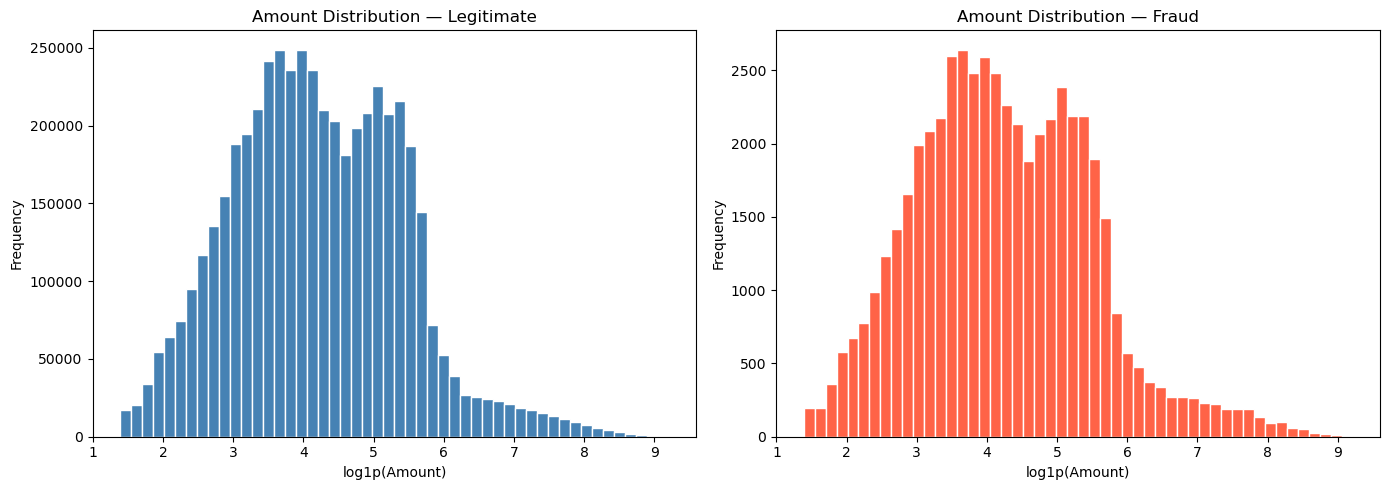

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.log1p(txn_data[txn_data['is_fraud'] == 0]['amount'].dropna()).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Amount Distribution — Legitimate')
axes[0].set_xlabel('log1p(Amount)')
axes[0].set_ylabel('Frequency')

np.log1p(txn_data[txn_data['is_fraud'] == 1]['amount'].dropna()).plot(
    kind='hist', bins=50, ax=axes[1], color='tomato', edgecolor='white'
)
axes[1].set_title('Amount Distribution — Fraud')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [59]:
# amount is a weak predictor

print(txn_data.groupby('is_fraud')['amount'].describe().T)

is_fraud            0          1
count    4947295.0000 52705.0000
mean         161.2368   180.9098
std          402.9094   465.0726
min            3.0000     3.0000
25%           26.9500    27.2300
50%           61.3400    62.5100
75%          160.0000   165.6500
max        10000.0000 10000.0000


In [60]:
# Feature 1 — Amount relative to account's own history
txn_data['amount_vs_acc_mean'] = (
    txn_data['amount'] /
    txn_data.groupby('account_id')['amount'].transform('mean')
)

# Feature 2 — Z-score of amount per account
txn_data['amount_zscore'] = (
    txn_data.groupby('account_id')['amount']
    .transform(lambda x: (x - x.mean()) / x.std())
)


In [61]:
txn_data[['amount', 'amount_vs_acc_mean', 'amount_zscore']].head()

,amount,amount_vs_acc_mean,amount_zscore
0,80.0000,0.4737,-0.3696
1,22.4600,0.2070,-0.6430
2,34.1700,0.1538,-0.2826
3,28.6700,0.2395,-0.6292
4,100.0000,0.7863,-0.1087


<Axes: xlabel='amt_zscore_groups'>

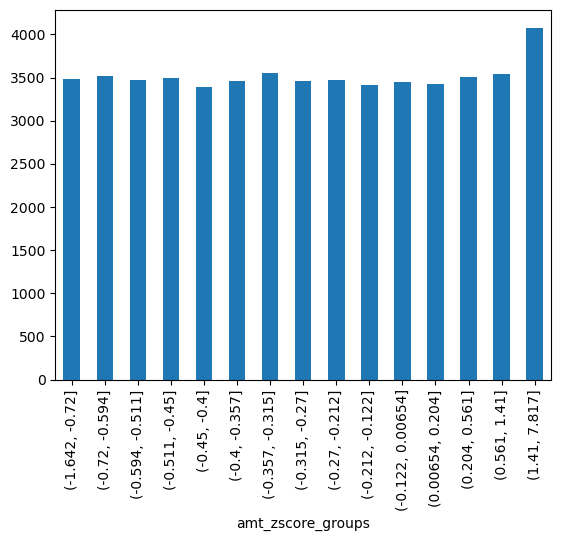

In [62]:
txn_data['amt_zscore_groups'] = pd.qcut(txn_data['amount_zscore'], q=15, duplicates='drop')
txn_data.groupby('amt_zscore_groups')['is_fraud'].sum().plot(kind='bar')

In [63]:
# amount itself is not an indicater for diffrentiating the fraud

In [80]:
txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud,amount_bin,amount_vs_acc_mean,amount_zscore,amt_zscore_groups,is_night_transaction
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0,"(61.35, 90.0]",0.4737,-0.3696,"(-0.4, -0.357]",0
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0,"(22.04, 32.03]",0.2070,-0.6430,"(-0.72, -0.594]",0
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0,"(32.03, 44.55]",0.1538,-0.2826,"(-0.315, -0.27]",0
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0,"(22.04, 32.03]",0.2395,-0.6292,"(-0.72, -0.594]",0
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0,"(90.0, 133.86]",0.7863,-0.1087,"(-0.122, 0.00654]",0


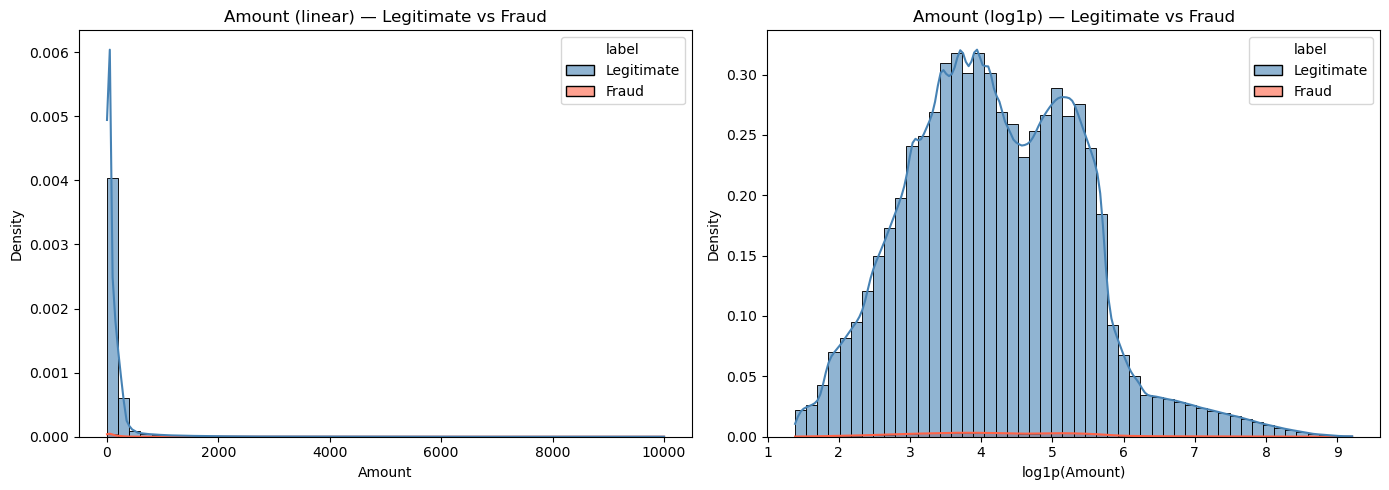


Amount (raw) summary:
  Legitimate: n=4,947,295, mean=161.24, median=61.34, std=402.91
  Fraud     : n=52,705, mean=180.91, median=62.51, std=465.07

Amount (log1p) summary:
  Legitimate: n=4,947,295, mean=4.21, median=4.13, std=1.23
  Fraud     : n=52,705, mean=4.25, median=4.15, std=1.27
  Legitimate: n=4,947,295, mean=4.21, median=4.13, std=1.23
  Fraud     : n=52,705, mean=4.25, median=4.15, std=1.27


In [82]:
# Amount distribution subplots: linear (left) and log1p (right)
import matplotlib.pyplot as plt
import seaborn as sns

tmp = txn_data.copy()
# ensure numeric
tmp['amount'] = pd.to_numeric(tmp['amount'], errors='coerce')
tmp['amount_log'] = np.log1p(tmp['amount'])
# readable labels
tmp['label'] = tmp['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear-scale histogram
sns.histplot(data=tmp, x='amount', hue='label', bins=50, kde=True, stat='density', ax=axes[0], alpha=0.6, palette=['steelblue','tomato'])
axes[0].set_title('Amount (linear) — Legitimate vs Fraud')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')

# Log-scale histogram
sns.histplot(data=tmp, x='amount_log', hue='label', bins=50, kde=True, stat='density', ax=axes[1], alpha=0.6, palette=['steelblue','tomato'])
axes[1].set_title('Amount (log1p) — Legitimate vs Fraud')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Quick numeric summary for both scales
for col, name in [('amount', 'Amount (raw)'), ('amount_log', 'Amount (log1p)')]:
    print(f"\n{name} summary:")
    for lab in ['Legitimate', 'Fraud']:
        s = tmp.loc[tmp['label'] == lab, col].dropna()
        print(f"  {lab:10s}: n={len(s):,}, mean={s.mean():.2f}, median={s.median():.2f}, std={s.std():.2f}")


Point-biserial correlation (log_amount vs is_fraud): r = 0.0029,  p-value = 7.3395e-11
Mann-Whitney U test: statistic = 131741560220,  p-value = 3.3214e-05
Median log_amount - Legitimate: 4.1326,  Fraud: 4.1512


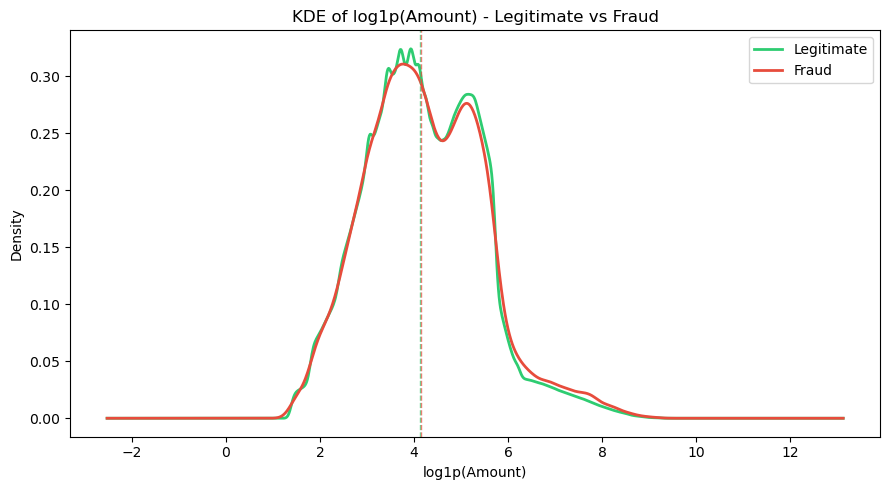

Interpretation:
  log_amount is positively correlated with fraud (weak, r=0.0029) - statistically significant (p=7.34e-11)
  Mann-Whitney confirms the distributions differ significantly (p=3.32e-05)


In [86]:
# --- log(amount) vs is_fraud correlation analysis
from scipy import stats

# 1. Create log-transformed column; cast both columns to float to avoid object-dtype errors
txn_data["log_amount"] = np.log1p(txn_data["amount"])
is_fraud_num = pd.to_numeric(txn_data["is_fraud"], errors="coerce")
log_amount_num = pd.to_numeric(txn_data["log_amount"], errors="coerce")

# Drop rows where either value is NaN after coercion
mask = is_fraud_num.notna() & log_amount_num.notna()
is_fraud_clean = is_fraud_num[mask].astype(float)
log_amount_clean = log_amount_num[mask].astype(float)

# 2. Point-biserial correlation
pb_corr, pb_pval = stats.pointbiserialr(is_fraud_clean, log_amount_clean)
print(f"Point-biserial correlation (log_amount vs is_fraud): r = {pb_corr:.4f},  p-value = {pb_pval:.4e}")

# 3. Mann-Whitney U test
legit_amounts = log_amount_clean[is_fraud_clean == 0]
fraud_amounts = log_amount_clean[is_fraud_clean == 1]
mw_stat, mw_pval = stats.mannwhitneyu(fraud_amounts, legit_amounts, alternative="two-sided")
print(f"Mann-Whitney U test: statistic = {mw_stat:.0f},  p-value = {mw_pval:.4e}")
print(f"Median log_amount - Legitimate: {legit_amounts.median():.4f},  Fraud: {fraud_amounts.median():.4f}")

# 4. KDE plot
plt.figure(figsize=(9, 5))
legit_amounts.plot.kde(label="Legitimate", color="#2ecc71", linewidth=2)
fraud_amounts.plot.kde(label="Fraud", color="#e74c3c", linewidth=2)
plt.axvline(legit_amounts.median(), color="#2ecc71", linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(fraud_amounts.median(), color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)
plt.title("KDE of log1p(Amount) - Legitimate vs Fraud")
plt.xlabel("log1p(Amount)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Interpretation
print("Interpretation:")
direction = "positively" if pb_corr > 0 else "negatively"
strength = "weak" if abs(pb_corr) < 0.1 else "moderate" if abs(pb_corr) < 0.3 else "strong"
sig = "statistically significant" if pb_pval < 0.05 else "NOT statistically significant"
print(f"  log_amount is {direction} correlated with fraud ({strength}, r={pb_corr:.4f}) - {sig} (p={pb_pval:.2e})")
print(f"  Mann-Whitney confirms the distributions {'differ significantly' if mw_pval < 0.05 else 'do NOT differ significantly'} (p={mw_pval:.2e})")

In [87]:
pb_pval<0.05

np.True_

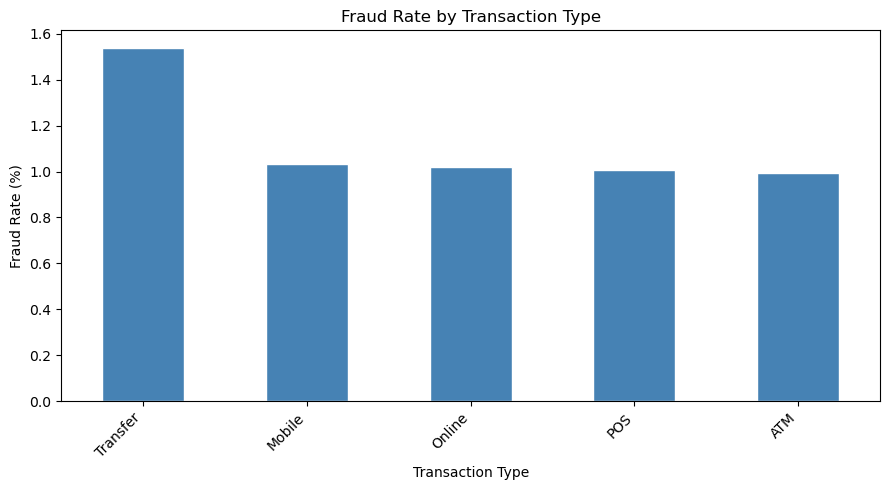

transaction_type
Transfer   1.5380
Mobile     1.0314
Online     1.0178
POS        1.0087
ATM        0.9925
Name: is_fraud, dtype: object


In [65]:
# Fraud rate by transaction type
fraud_by_txn_type = txn_data.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
fraud_by_txn_type.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(fraud_by_txn_type)

In [66]:
txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud,amount_bin,amount_vs_acc_mean,amount_zscore,amt_zscore_groups
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0,"(61.35, 90.0]",0.4737,-0.3696,"(-0.4, -0.357]"
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0,"(22.04, 32.03]",0.2070,-0.6430,"(-0.72, -0.594]"
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0,"(32.03, 44.55]",0.1538,-0.2826,"(-0.315, -0.27]"
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0,"(22.04, 32.03]",0.2395,-0.6292,"(-0.72, -0.594]"
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0,"(90.0, 133.86]",0.7863,-0.1087,"(-0.122, 0.00654]"


In [67]:
# Merchant category
txn_data.merchant_category.unique()

array(['ATM Withdrawal', 'Restaurant/Cafe', 'Supermarket',
       'Travel/Hotels', 'Utilities/Bills', 'Transfer', 'Online Retail',
       'Crypto/Gaming', 'Other', 'Transport/Fuel', 'Healthcare',
       'Entertainment'], dtype=object)

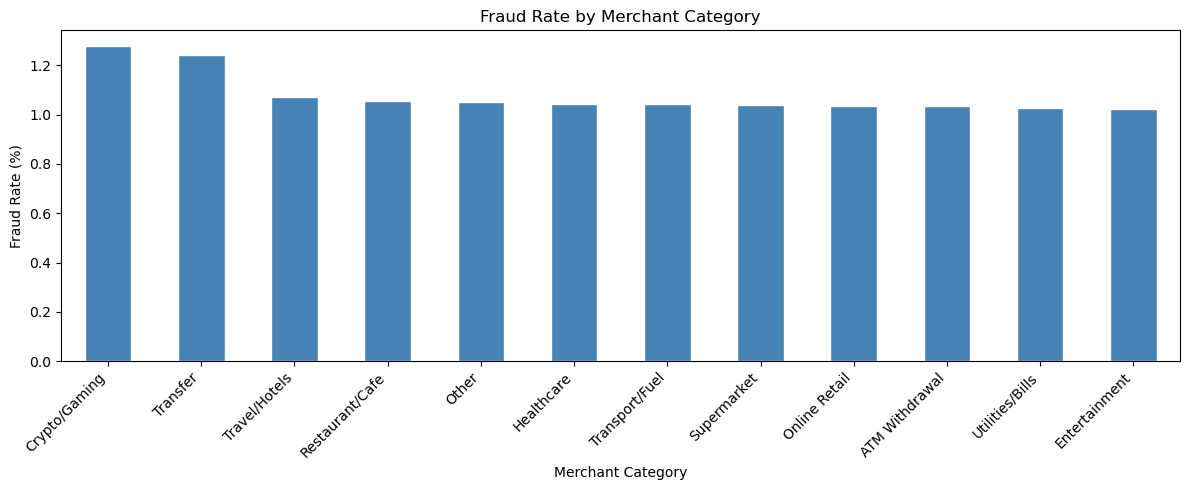

merchant_category
Crypto/Gaming     1.2784
Transfer          1.2414
Travel/Hotels     1.0707
Restaurant/Cafe   1.0555
Other             1.0524
Healthcare        1.0421
Transport/Fuel    1.0416
Supermarket       1.0388
Online Retail     1.0369
ATM Withdrawal    1.0342
Utilities/Bills   1.0275
Entertainment     1.0245
Name: is_fraud, dtype: object


In [68]:
# Fraud rate by merchant category
fraud_by_merchant = txn_data.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
fraud_by_merchant.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(fraud_by_merchant)

In [69]:
txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud,amount_bin,amount_vs_acc_mean,amount_zscore,amt_zscore_groups
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0,"(61.35, 90.0]",0.4737,-0.3696,"(-0.4, -0.357]"
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0,"(22.04, 32.03]",0.2070,-0.6430,"(-0.72, -0.594]"
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0,"(32.03, 44.55]",0.1538,-0.2826,"(-0.315, -0.27]"
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0,"(22.04, 32.03]",0.2395,-0.6292,"(-0.72, -0.594]"
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0,"(90.0, 133.86]",0.7863,-0.1087,"(-0.122, 0.00654]"


hour_od_day column

In [70]:
txn_data['hour_of_day'].dtype

dtype('int64')

<Axes: xlabel='hour_of_day'>

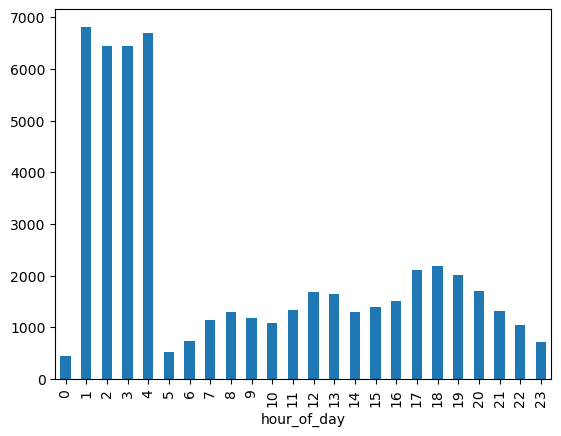

In [71]:
txn_data.groupby('hour_of_day')['is_fraud'].sum().plot(kind='bar')

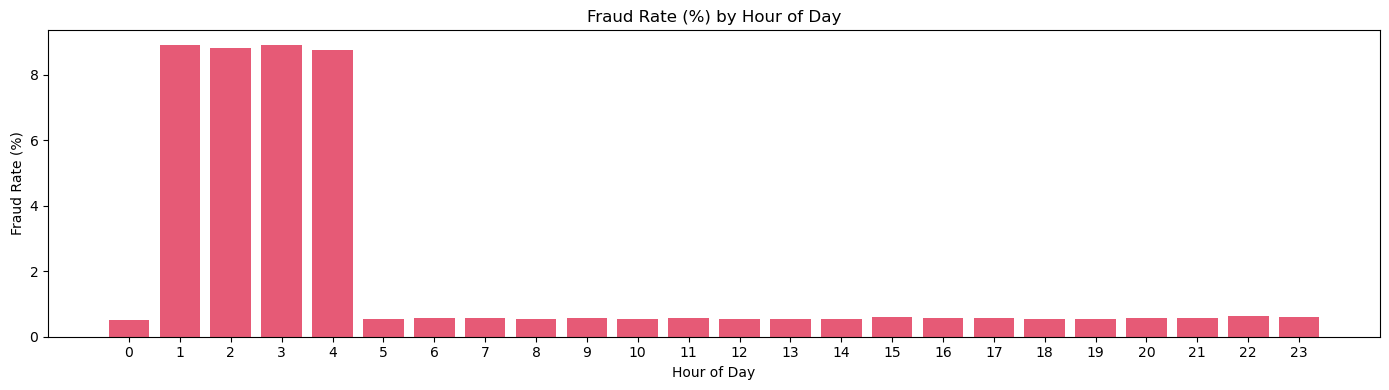

In [72]:
fraud_rate_by_hour = (
    txn_data.groupby('hour_of_day')['is_fraud']
    .mean() * 100
).round(2)

plt.figure(figsize=(14, 4))
plt.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, 
        color='crimson', alpha=0.7)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [73]:
# Now, I am going to create a new feature saying that, "is_night_transaction" 

txn_data['is_night_transaction'] = txn_data['hour_of_day'].between(1, 4).astype(int)

In [74]:
txn_data.head()

,transaction_id,account_id,timestamp,amount,transaction_type,merchant_category,merchant_id,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud,amount_bin,amount_vs_acc_mean,amount_zscore,amt_zscore_groups,is_night_transaction
0,TXN00000001,ACC0013346,2023-04-06 15:07:27,80.0000,ATM,ATM Withdrawal,MER07663,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0,"(61.35, 90.0]",0.4737,-0.3696,"(-0.4, -0.357]",0
1,TXN00000002,ACC0116127,2023-09-07 12:44:50,22.4600,Mobile,Restaurant/Cafe,MER12679,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0,"(22.04, 32.03]",0.2070,-0.6430,"(-0.72, -0.594]",0
2,TXN00000003,ACC0098236,2023-09-24 10:42:02,34.1700,Online,Supermarket,MER06456,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0,"(32.03, 44.55]",0.1538,-0.2826,"(-0.315, -0.27]",0
3,TXN00000004,ACC0065861,2023-07-01 08:10:15,28.6700,POS,Restaurant/Cafe,MER01463,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0,"(22.04, 32.03]",0.2395,-0.6292,"(-0.72, -0.594]",0
4,TXN00000005,ACC0064986,2024-11-22 19:40:08,100.0000,Online,ATM Withdrawal,MER30564,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0,"(90.0, 133.86]",0.7863,-0.1087,"(-0.122, 0.00654]",0


In [75]:
cust_data.head()

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since,cust_tenure_days,cust_tenure_years
0,CUST000001,working_adult,32,40063,711,Employed,South East,2008-09-04,5052,13.8316
1,CUST000002,retired,82,24101,721,Retired,East Midlands,2021-08-17,322,0.8816
2,CUST000003,established,64,77965,847,Self-Employed,Wales,2013-06-06,3316,9.0787
3,CUST000004,working_adult,46,69238,775,Employed,South West,2018-08-12,1423,3.8960
4,CUST000005,young_adult,25,18823,584,Self-Employed,North West,2015-03-19,2665,7.2964


In [76]:
acc_data.head()

,account_id,customer_id,account_type,account_open_date,account_balance,account_status
0,ACC0000001,CUST000001,Current,2018-03-25,20769.9000,Active
1,ACC0000002,CUST000002,Current,2017-05-19,31048.5700,Active
2,ACC0000003,CUST000003,Current,2014-12-31,47146.9500,Active
3,ACC0000004,CUST000004,Current,2021-01-05,1151.7100,Active
4,ACC0000005,CUST000005,Current,2019-04-13,966.3700,Active


In [ ]:
# placeholder

In [ ]:
# Join all 3 datasets — one row per transaction
# Path: txn_data → acc_data (account_id) → cust_data (customer_id)

df = (
    txn_data
    .merge(acc_data, on='account_id', how='left')
    .merge(cust_data, on='customer_id', how='left')
)

# Drop ID and date columns not needed for modelling
drop_cols = ['transaction_id', 'account_id', 'customer_id', 'merchant_id',
             'timestamp', 'account_open_date', 'customer_since', 'amount_bin']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(df.shape)
print(df.dtypes)

(5000000, 31)
amount                          float64
transaction_type                 object
merchant_category                object
currency                         object
is_foreign_currency               int64
hour_of_day                       int64
day_of_week                       int64
is_weekend                        int64
days_since_last_transaction       int64
previous_transaction_amount     float64
login_attempts                    int64
device_change_flag                int64
location_change_flag              int64
ip_country_mismatch               int64
failed_pin_attempts               int64
is_fraud                         object
amount_vs_acc_mean              float64
amount_zscore                   float64
amt_zscore_groups              category
is_night_transaction              int64
account_type                     object
account_balance                 float64
account_status                   object
segment                          object
customer_age              

In [ ]:
df.head()

,amount,transaction_type,merchant_category,currency,is_foreign_currency,hour_of_day,day_of_week,is_weekend,days_since_last_transaction,previous_transaction_amount,login_attempts,device_change_flag,location_change_flag,ip_country_mismatch,failed_pin_attempts,is_fraud,amount_vs_acc_mean,amount_zscore,amt_zscore_groups,is_night_transaction,account_type,account_balance,account_status,segment,customer_age,annual_income,credit_score,occupation,region,cust_tenure_days,cust_tenure_years
0,80.0000,ATM,ATM Withdrawal,GBP,0,15,3,0,13,187.1500,1,0,0,0,0,0,0.4737,-0.3696,"(-0.4, -0.357]",0,Current,17845.6100,Active,working_adult,44,62971,728,Employed,Yorkshire,129,0.3532
1,22.4600,Mobile,Restaurant/Cafe,GBP,0,11,3,0,27,137.7300,1,0,0,0,0,0,0.2070,-0.6430,"(-0.72, -0.594]",0,Current,1435.1900,Active,young_adult,22,18643,686,Student,North West,4026,11.0226
2,34.1700,Online,Supermarket,GBP,0,19,6,1,25,165.9100,2,0,0,0,1,0,0.1538,-0.2826,"(-0.315, -0.27]",0,Savings,19629.1600,Active,working_adult,36,47252,800,Employed,Yorkshire,4434,12.1396
3,28.6700,POS,Restaurant/Cafe,GBP,0,18,5,1,17,124.1800,1,0,1,0,0,0,0.2395,-0.6292,"(-0.72, -0.594]",0,Current,790.5700,Active,young_adult,23,29567,686,Employed,East Midlands,2359,6.4586
4,100.0000,Online,ATM Withdrawal,GBP,0,20,4,0,1,149.3400,4,0,0,0,0,0,0.7863,-0.1087,"(-0.122, 0.00654]",0,Savings,8143.0000,Active,young_adult,18,25975,680,Student,East Midlands,930,2.5462


In [ ]:
df1 = df.copy()

In [ ]:
df2 = df1.drop(['currency','amt_zscore_groups','cust_tenure_days'], axis = 1)

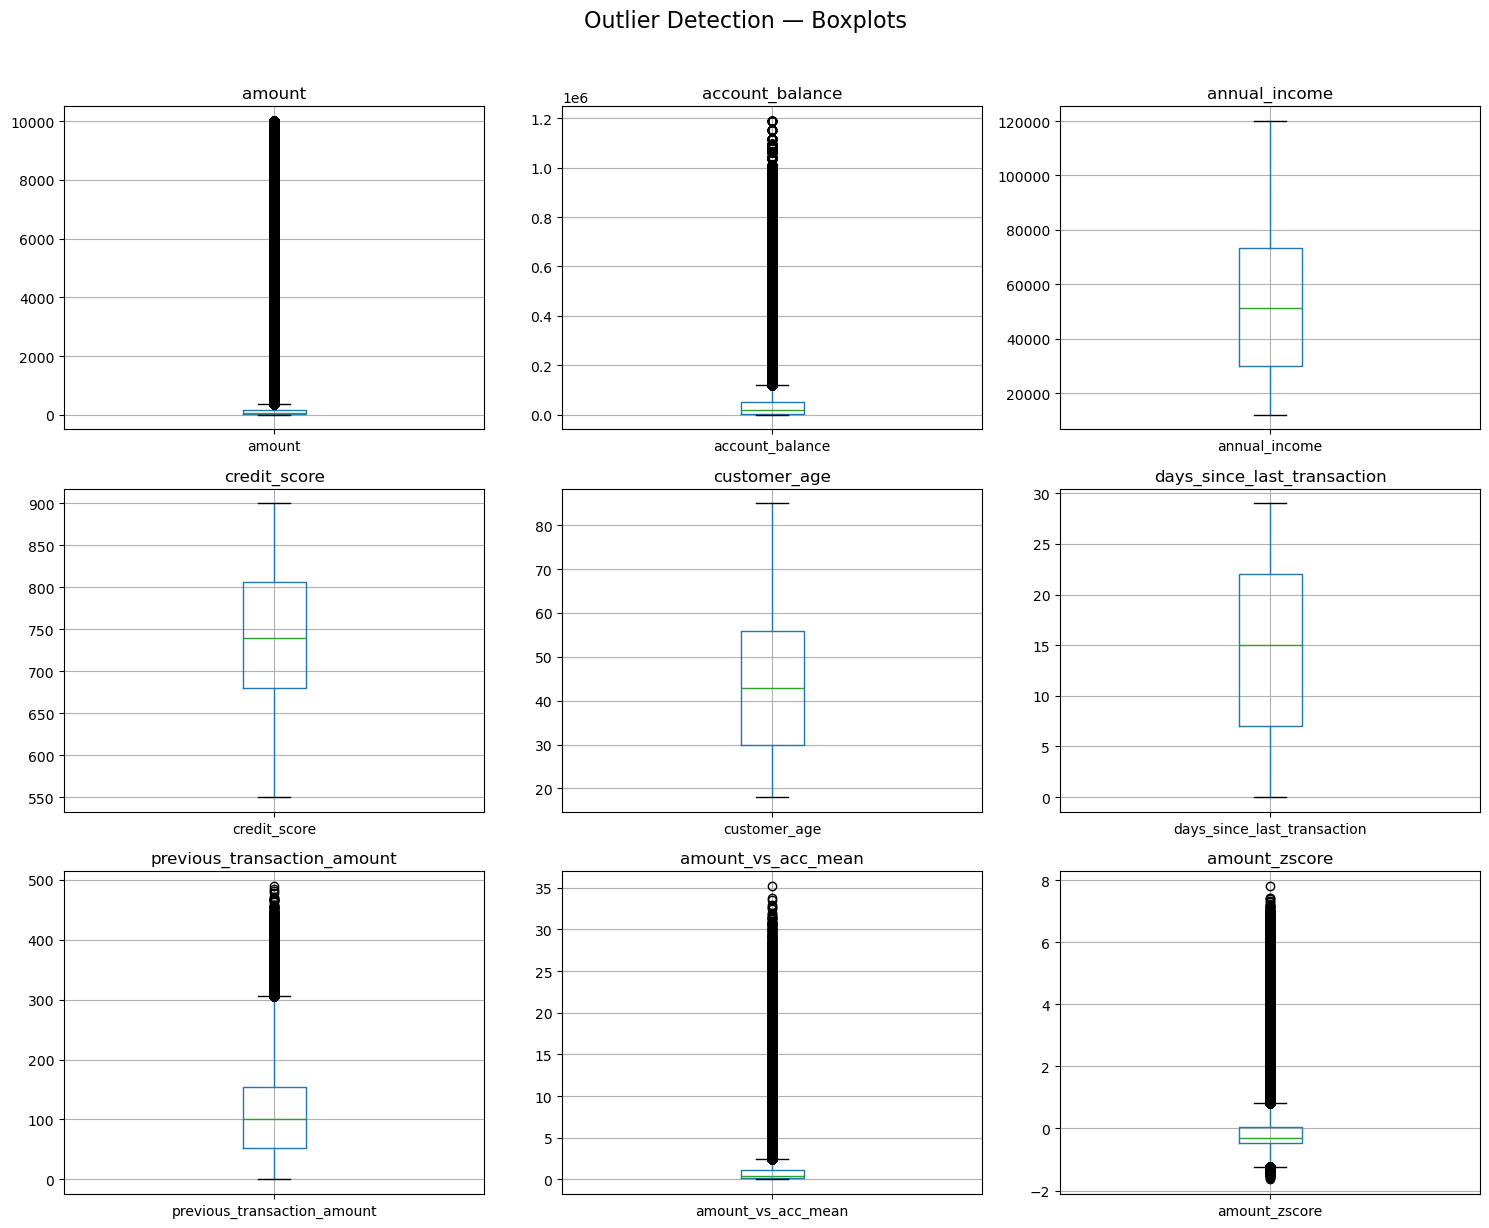

Outlier counts (IQR method):
  amount: 341,864 outliers — fraud rate in outliers: 1.25%
  account_balance: 409,652 outliers — fraud rate in outliers: 1.02%
  annual_income: 0 outliers — fraud rate in outliers: nan%
  credit_score: 0 outliers — fraud rate in outliers: nan%
  customer_age: 0 outliers — fraud rate in outliers: nan%
  days_since_last_transaction: 0 outliers — fraud rate in outliers: nan%
  previous_transaction_amount: 24,735 outliers — fraud rate in outliers: 1.08%
  amount_vs_acc_mean: 403,853 outliers — fraud rate in outliers: 1.21%
  amount_zscore: 527,600 outliers — fraud rate in outliers: 1.17%


In [ ]:
# Outlier detection — boxplots for key numerical features
num_cols = ['amount', 'account_balance', 'annual_income', 'credit_score',
            'customer_age', 'days_since_last_transaction', 'previous_transaction_amount',
            'amount_vs_acc_mean', 'amount_zscore']

# Keep only columns that exist in df
num_cols = [c for c in num_cols if c in df2.columns]

n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df2.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# IQR-based outlier count per column
print("Outlier counts (IQR method):")
for col in num_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df2[(df2[col] < Q1 - 1.5 * IQR) | (df2[col] > Q3 + 1.5 * IQR)]
    fraud_in_outliers = outliers['is_fraud'].mean() * 100
    print(f"  {col}: {len(outliers):,} outliers — fraud rate in outliers: {fraud_in_outliers:.2f}%")

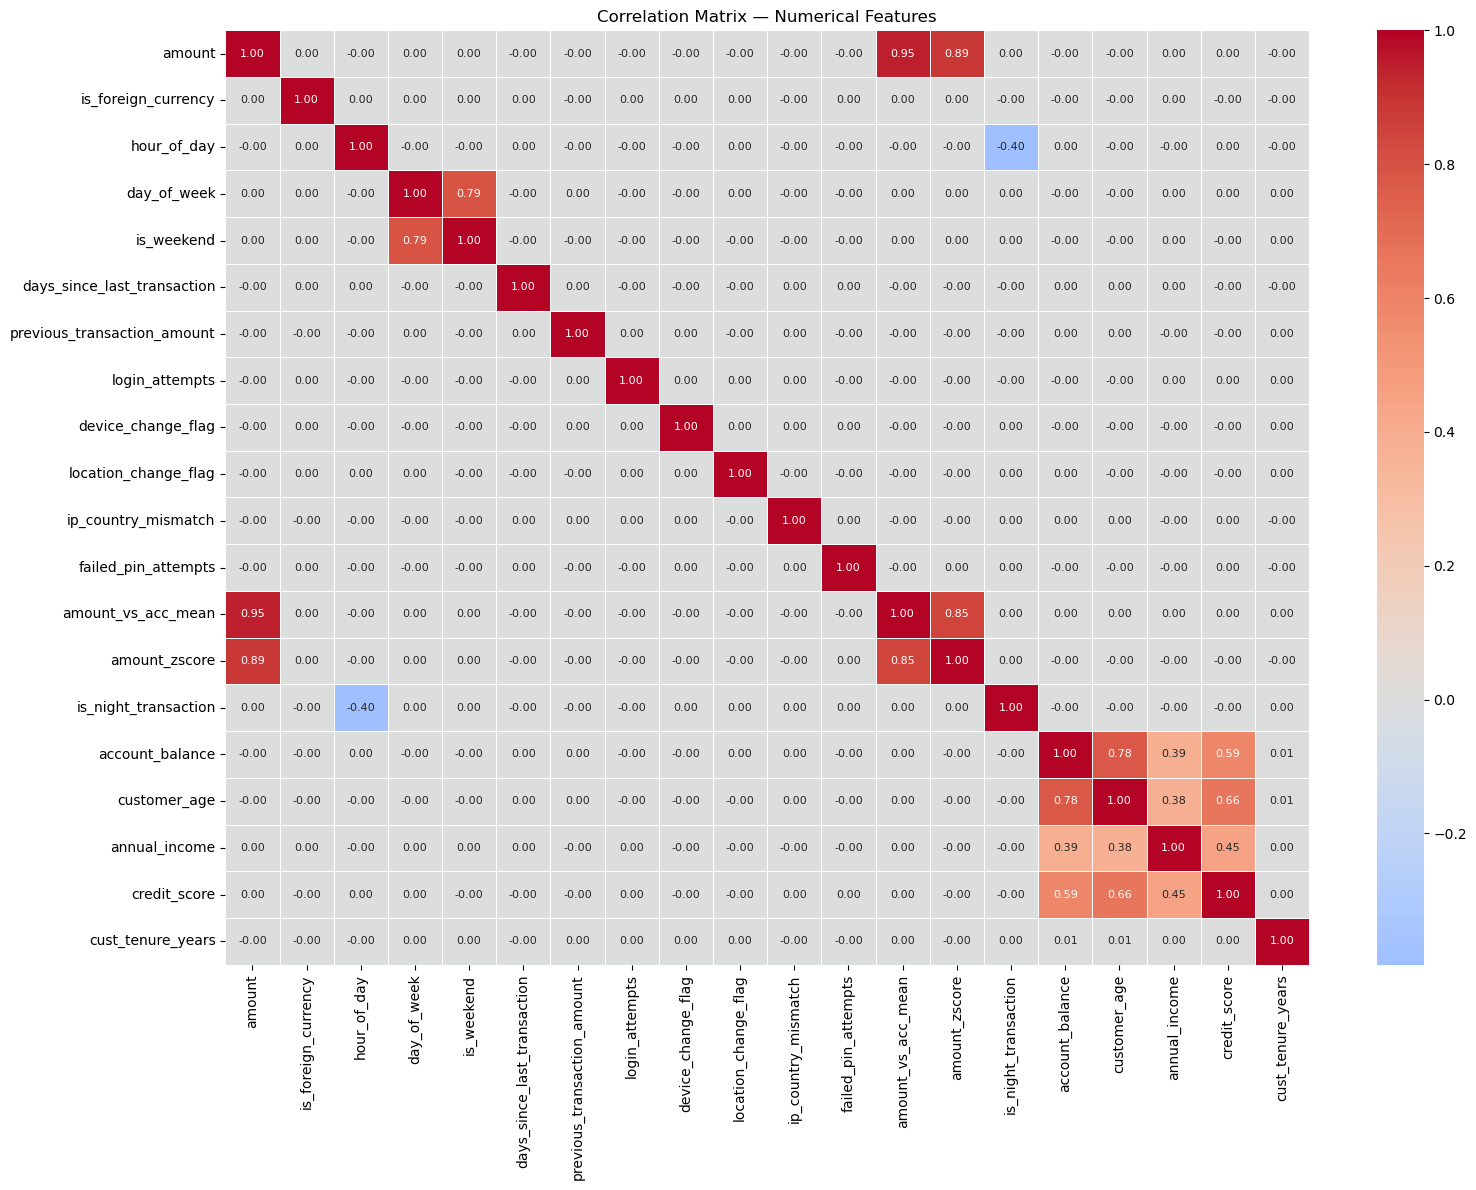

Correlation with is_fraud:


KeyError: 'is_fraud'

In [ ]:
# Correlation heatmap — numerical features vs is_fraud
num_df = df2.select_dtypes(include='number')

corr = num_df.corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

# Correlation with target only
print("Correlation with is_fraud:")
print(corr['is_fraud'].drop('is_fraud').sort_values(ascending=False).to_string())

(5000000, 31)

In [ ]:
# --- Spearman Correlation: Continuous features vs is_fraud ---
from scipy.stats import spearmanr

continuous_cols = ['amount', 'account_balance', 'annual_income', 'credit_score',
                   'customer_age', 'days_since_last_transaction',
                   'previous_transaction_amount', 'amount_vs_acc_mean',
                   'amount_zscore', 'cust_tenure_years']

continuous_cols = [c for c in continuous_cols if c in df2.columns]

print("Spearman Correlation with is_fraud:")
print(f"{'Feature':<35} {'Correlation':>12} {'p-value':>12}")
print("-" * 62)
for col in continuous_cols:
    corr, p = spearmanr(df2[col].dropna(), df2.loc[df2[col].notna(), 'is_fraud'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{col:<35} {corr:>12.4f} {p:>12.4e} {sig}")

Spearman Correlation with is_fraud:
Feature                              Correlation      p-value
--------------------------------------------------------------
amount                                    0.0019   3.3214e-05 ***
account_balance                          -0.0008   7.6318e-02 
annual_income                            -0.0006   1.7660e-01 
credit_score                             -0.0002   6.5345e-01 
customer_age                             -0.0000   9.4314e-01 
days_since_last_transaction               0.0009   4.2629e-02 *
previous_transaction_amount               0.0001   8.4264e-01 
amount_vs_acc_mean                        0.0020   1.1767e-05 ***
amount_zscore                             0.0020   1.2242e-05 ***
cust_tenure_years                         0.0005   2.3759e-01 


In [ ]:
# --- Chi-Square Test: Binary/Categorical features vs is_fraud ---
from scipy.stats import chi2_contingency

binary_cat_cols = ['is_foreign_currency', 'is_weekend', 'device_change_flag',
                   'location_change_flag', 'ip_country_mismatch',
                   'transaction_type', 'merchant_category', 'currency',
                   'account_type', 'account_status', 'segment', 'occupation', 'region']

binary_cat_cols = [c for c in binary_cat_cols if c in df2.columns]

print("Chi-Square Test with is_fraud:")
print(f"{'Feature':<30} {'Chi2':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 70)
for col in binary_cat_cols:
    ct = pd.crosstab(df2[col], df['is_fraud'])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = 'Yes ***' if p < 0.001 else 'Yes **' if p < 0.01 else 'Yes *' if p < 0.05 else 'No'
    print(f"{col:<30} {chi2:>12.2f} {p:>12.4e} {sig:>12}")

Chi-Square Test with is_fraud:
Feature                                Chi2      p-value  Significant
----------------------------------------------------------------------
is_foreign_currency                  104.66   1.4531e-24      Yes ***
is_weekend                             0.00   9.5830e-01           No
device_change_flag                  1916.42   0.0000e+00      Yes ***
location_change_flag                  88.48   5.1309e-21      Yes ***
ip_country_mismatch                   48.16   3.9209e-12      Yes ***
transaction_type                     980.41  6.2884e-211      Yes ***
merchant_category                    135.96   1.0782e-23      Yes ***
account_type                           4.11   1.2810e-01           No
account_status                         0.00   1.0000e+00           No
segment                                0.48   9.2424e-01           No
occupation                             7.57   1.8146e-01           No
region                                 6.65   8.2686e-01  

In [ ]:
# Drop features with no statistical relationship with is_fraud
drop_cols = [
    'segment', 'occupation', 'region',
    'account_type', 'account_status', 'is_weekend',
    'customer_age', 'annual_income', 'credit_score',
    'cust_tenure_years', 'account_balance', 'previous_transaction_amount'
]

drop_cols = [c for c in drop_cols if c in df2.columns]
df3 = df2.drop(columns=drop_cols)

print(f"Remaining features: {df.shape[1]}")
print(df.columns.tolist())

Remaining features: 19
['amount', 'transaction_type', 'merchant_category', 'currency', 'is_foreign_currency', 'hour_of_day', 'day_of_week', 'days_since_last_transaction', 'login_attempts', 'device_change_flag', 'location_change_flag', 'ip_country_mismatch', 'failed_pin_attempts', 'is_fraud', 'amount_vs_acc_mean', 'amount_zscore', 'amt_zscore_groups', 'is_night_transaction', 'cust_tenure_days']


In [ ]:
df3['amount_log'] = np.log1p(df3['amount'])

In [ ]:
df3.dtypes

amount                         float64
transaction_type                object
merchant_category               object
is_foreign_currency              int64
hour_of_day                      int64
day_of_week                      int64
days_since_last_transaction      int64
login_attempts                   int64
device_change_flag               int64
location_change_flag             int64
ip_country_mismatch              int64
failed_pin_attempts              int64
is_fraud                        object
amount_vs_acc_mean             float64
amount_zscore                  float64
is_night_transaction             int64
amount_log                     float64
dtype: object

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline  # changed: imblearn Pipeline supports SMOTE step
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE             # added: SMOTE for oversampling
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# --- Drop NaNs and Interval columns before modelling ---
df_model = df3.copy()
df_model = df_model[df_model['is_fraud'].notna()]
df_model = df_model.select_dtypes(exclude='interval')
df_model['is_fraud'] = df_model['is_fraud'].astype(int)

# --- Define feature groups ---
label_cols  = [c for c in ['transaction_type', 'currency'] if c in df_model.columns]
target_cols = [c for c in ['merchant_category'] if c in df_model.columns]
num_cols    = [c for c in df_model.columns if c not in label_cols + target_cols + ['is_fraud']]

print("Label encode  :", label_cols)
print("Target encode :", target_cols)
print("Passthrough   :", num_cols)

# --- Train / Test Split ---
X = df_model.drop(columns='is_fraud')
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraud rate — Train: {y_train.mean():.4f} | Test: {y_test.mean():.4f}")

# --- Preprocessor ---
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), label_cols),
    ('target',  TargetEncoder(),                                                      target_cols),
    ('num',     'passthrough',                                                        num_cols),
], remainder='drop')

# --- Pipeline with SMOTE ---
# Changes:
# 1. ImbPipeline instead of sklearn Pipeline — supports resampling steps
# 2. SMOTE added after preprocessing, before model
# 3. sampling_strategy=0.1 — brings fraud to 10% of legitimate (realistic, avoids over-inflation)
# 4. scale_pos_weight removed — SMOTE handles imbalance now
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ))
])

# --- Train ---
pipeline.fit(X_train, y_train)
print("\nPipeline training complete.")

Label encode  : ['transaction_type']
Target encode : ['merchant_category']
Passthrough   : ['amount', 'is_foreign_currency', 'hour_of_day', 'day_of_week', 'days_since_last_transaction', 'login_attempts', 'device_change_flag', 'location_change_flag', 'ip_country_mismatch', 'failed_pin_attempts', 'amount_vs_acc_mean', 'amount_zscore', 'is_night_transaction', 'amount_log']

Train: (4000000, 16) | Test: (1000000, 16)
Fraud rate — Train: 0.0105 | Test: 0.0105

Pipeline training complete.


In [ ]:
# # --- Full Pipeline ---
# pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles class imbalance
#         eval_metric='aucpr',
#         random_state=42,
#         n_jobs=-1
#     ))
# ])

# # --- Train ---
# pipeline.fit(X_train, y_train)
# print("\nPipeline training complete.")

In [ ]:
# --- Evaluate ---
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99    989459
       Fraud       0.52      0.03      0.05     10541

    accuracy                           0.99   1000000
   macro avg       0.75      0.51      0.52   1000000
weighted avg       0.98      0.99      0.98   1000000



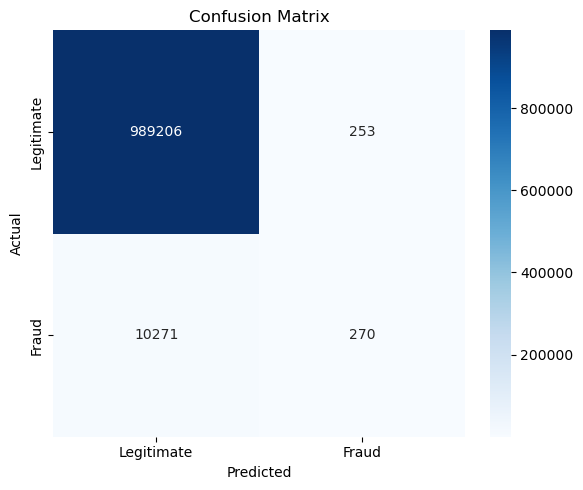

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
cust_data.query("customer_id == 'CUST090205'")  

,customer_id,segment,customer_age,annual_income,credit_score,occupation,region,customer_since,cust_tenure_days,cust_tenure_years
90204,CUST090205,established,61,93542,843,Self-Employed,Yorkshire,2020-09-25,648,1.7741



Amount statistics by fraud label:
              count     mean  median      std
is_fraud                                     
Legitimate  4947295 161.2368 61.3400 402.9094
Fraud         52705 180.9098 62.5100 465.0726

Mean amount — Legitimate: 161.24, Fraud: 180.91 — Fraud is 12.20% higher than Legitimate


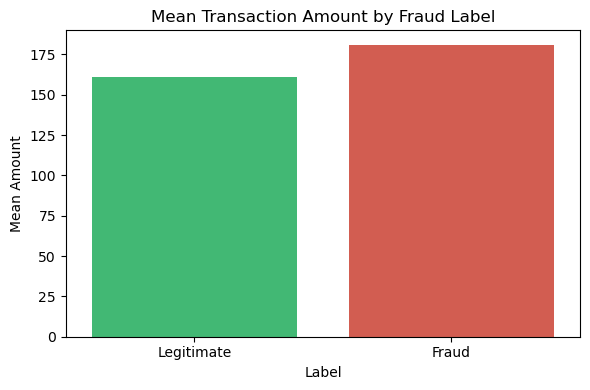


Amount statistics by fraud label:
              count     mean  median      std
is_fraud                                     
Legitimate  4947295 161.2368 61.3400 402.9094
Fraud         52705 180.9098 62.5100 465.0726

Mean amount — Legitimate: 161.24, Fraud: 180.91 — Fraud is 12.20% higher than Legitimate


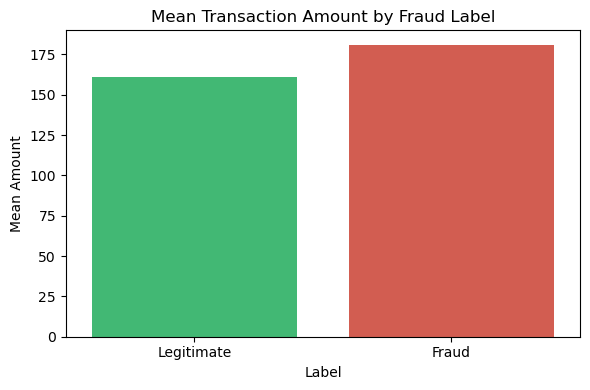

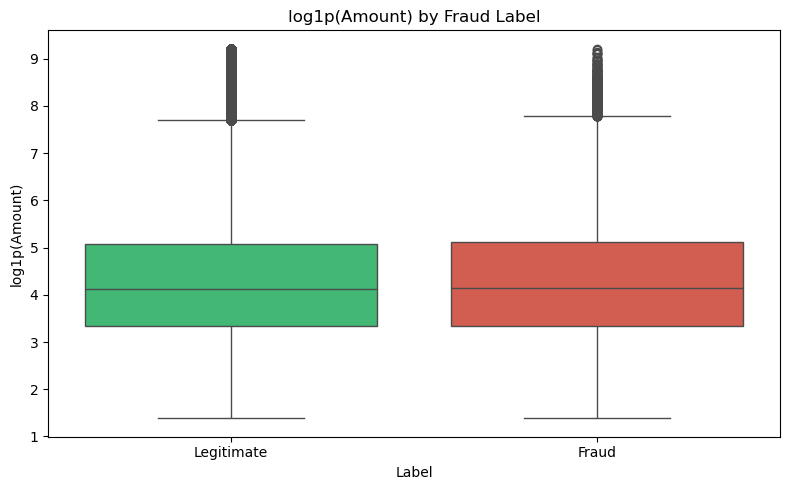


Amount statistics by fraud label:
              count     mean  median      std
is_fraud                                     
Legitimate  4947295 161.2368 61.3400 402.9094
Fraud         52705 180.9098 62.5100 465.0726

Mean amount — Legitimate: 161.24, Fraud: 180.91 — Fraud is 12.20% higher than Legitimate


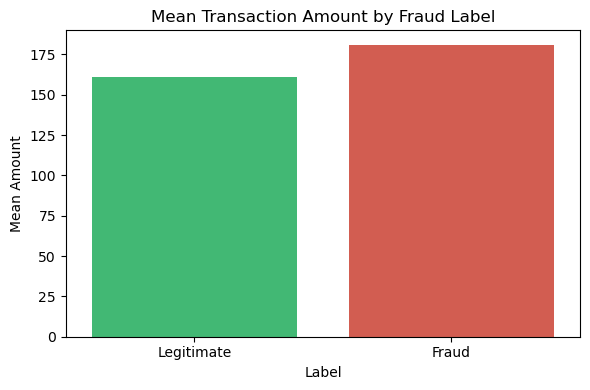

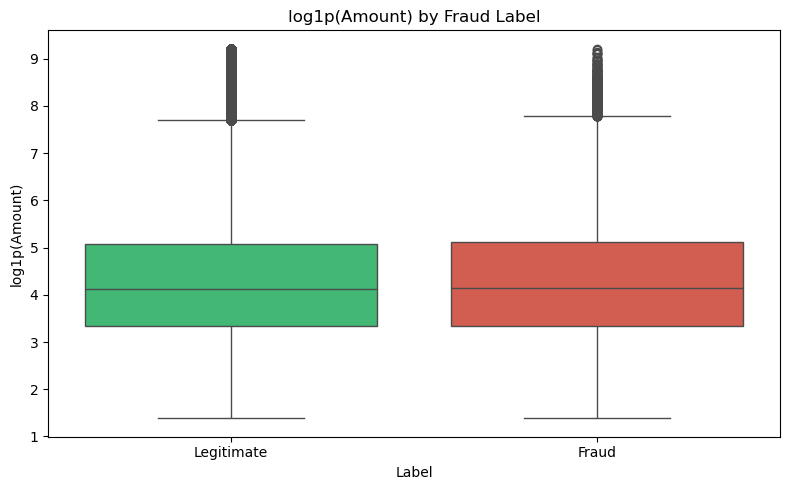

<Figure size 1000x500 with 0 Axes>


Amount statistics by fraud label:
              count     mean  median      std
is_fraud                                     
Legitimate  4947295 161.2368 61.3400 402.9094
Fraud         52705 180.9098 62.5100 465.0726

Mean amount — Legitimate: 161.24, Fraud: 180.91 — Fraud is 12.20% higher than Legitimate


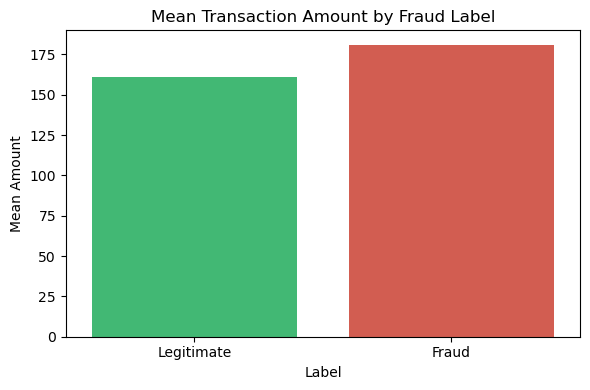

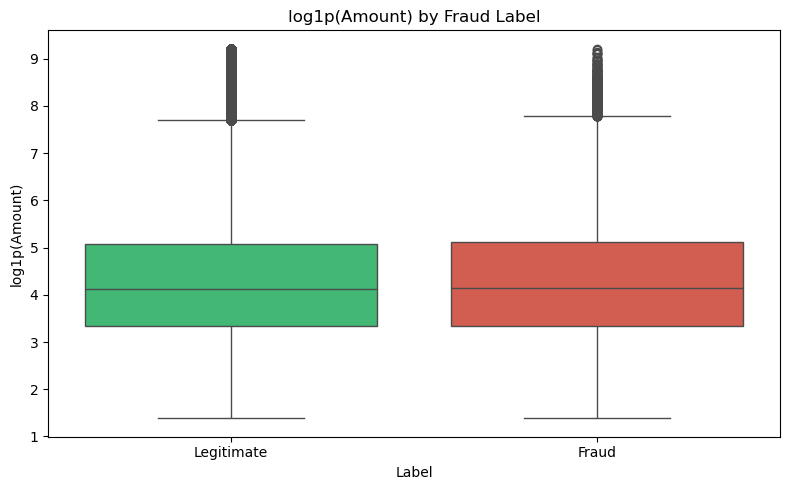

<Figure size 1000x500 with 0 Axes>

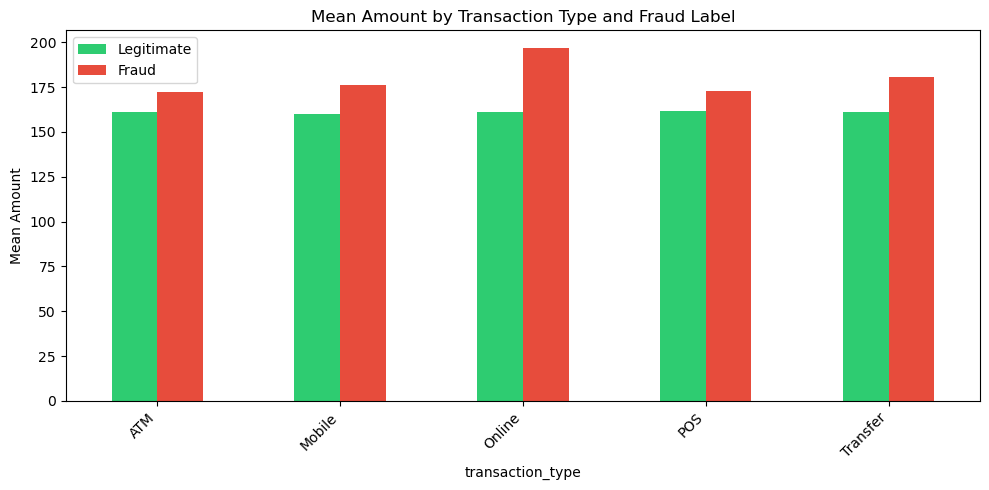


Transaction types with largest relative increase in mean amount for Fraud vs Legitimate:
                  Legitimate    Fraud  pct_diff
transaction_type                               
Online              161.0678 196.7868   22.1764
Transfer            161.1986 180.7843   12.1500
Mobile              160.2190 176.3401   10.0619
ATM                 161.1744 172.2272    6.8577
POS                 161.6438 172.6607    6.8155


In [78]:
# --- Amount vs Fraud: group averages and visualizations
# Overview: show mean/median/std of amount for legitimate vs fraud, a mean bar plot,
# a log-boxplot for distribution comparison, and mean amount by transaction type.

group_stats = txn_data.groupby('is_fraud')['amount'].agg(['count', 'mean', 'median', 'std']).rename(index={0: 'Legitimate', 1: 'Fraud'})
print('\nAmount statistics by fraud label:')
print(group_stats)

# Percent difference (relative change) between Fraud and Legitimate
if 0 in txn_data['is_fraud'].unique() and 1 in txn_data['is_fraud'].unique():
    legit_mean = group_stats.loc['Legitimate', 'mean']
    fraud_mean = group_stats.loc['Fraud', 'mean']
    pct_diff = (fraud_mean - legit_mean) / legit_mean * 100 if legit_mean != 0 else np.nan
    print(f"\nMean amount — Legitimate: {legit_mean:.2f}, Fraud: {fraud_mean:.2f} — Fraud is {pct_diff:.2f}% {'higher' if pct_diff>0 else 'lower' if pct_diff<0 else 'same'} than Legitimate")

# Bar plot of mean amount by fraud label
plt.figure(figsize=(6, 4))
sns.barplot(x=group_stats.index, y=group_stats['mean'].values, palette=['#2ecc71', '#e74c3c'])
plt.title('Mean Transaction Amount by Fraud Label')
plt.ylabel('Mean Amount')
plt.xlabel('Label')
plt.tight_layout()
plt.show()

# Boxplot on log1p scale (reduces skew)
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y=np.log1p(txn_data['amount']), data=txn_data.replace({'is_fraud': {0: 'Legitimate', 1: 'Fraud'}}), palette=['#2ecc71', '#e74c3c'])
plt.title('log1p(Amount) by Fraud Label')
plt.xlabel('Label')
plt.ylabel('log1p(Amount)')
plt.tight_layout()
plt.show()

# Mean amount by transaction type and fraud label (side-by-side)
if 'transaction_type' in txn_data.columns:
    mean_by_type = txn_data.groupby(['transaction_type', 'is_fraud'])['amount'].mean().unstack(fill_value=0)
    mean_by_type.columns = ['Legitimate', 'Fraud']
    plt.figure(figsize=(10, 5))
    mean_by_type.plot(kind='bar', figsize=(10, 5), color=['#2ecc71', '#e74c3c'])
    plt.title('Mean Amount by Transaction Type and Fraud Label')
    plt.ylabel('Mean Amount')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Show transaction types where fraud mean >> legit mean
    if 'Fraud' in mean_by_type.columns and 'Legitimate' in mean_by_type.columns:
        mean_by_type['pct_diff'] = (mean_by_type['Fraud'] - mean_by_type['Legitimate']) / mean_by_type['Legitimate'].replace(0, np.nan) * 100
        print('\nTransaction types with largest relative increase in mean amount for Fraud vs Legitimate:')
        print(mean_by_type[['Legitimate','Fraud','pct_diff']].sort_values('pct_diff', ascending=False).head(10).to_string())
else:
    print('\nColumn "transaction_type" not found in txn_data; skipping per-type analysis.')
